# Data Analysis Project

## Questions 
### 1- Which cities place the most orders? | tables (customer, orders) | key (customer_id)
### 2- What is the most used payment method for each city? | tables(orders,customers,order payments) | keys(customer_id, then order_id)
### 3- Which cities have good reviews and bad reviews? | tables(customers,orders,order reviews) | keys(customer_id,then order_id)
### 4- How long do orders take to be delivered? | tables(orders)
### 5- What are the most ordered products in each city? | tables(customers,orders) | keys(order_id)
### 6- what is the repeat purchase rate of customers? | tables(customers,orders) | keys(order_id)
### 7- how many customers leave good vs. bad reviews and where are from? | tables(customers,orders,order_reviews) | keys(order_id)
### ----
### 8- which city generate the highest total revenue? | tables(orders,customers,order items) | keys(order_id)
### 9- How does the shipping cost (freight value) affect the purchase decision across different cities? tables(orders,customers,order_items) | keys(order_id)
### 10- What percentage of orders are delivered late? | tablse(orders)
### 11- How does late delivery impact the customer review score? | tables(orders,order reviews) | keys(order_id)
### 12- Which seller cities supply the most products? | tables(sellers, order items) | keys(seller_id)
### 13- What are the peak sales months or days of the week? | tables(orders)
### 14- At what time of day do most customers make their purchases? | tables(orders)

## 1.1 Import required libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os
from typing import Dict,List,Tuple


pd.set_option("display.max_columns",999)
pd.set_option('display.float_format', '{:,.2f}'.format)

## 1.2 Read Data

In [3]:
cust_df = pd.read_csv('data/olist_customers_dataset.csv')
geoloc_df = pd.read_csv('data/olist_geolocation_dataset.csv')
order_items_df = pd.read_csv('data/olist_order_items_dataset.csv')
order_payments_df = pd.read_csv('data/olist_order_payments_dataset.csv')
order_reviews_df = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('data/olist_orders_dataset.csv')
products_df = pd.read_csv('data/olist_products_dataset.csv')
sellers_df = pd.read_csv('data/olist_sellers_dataset.csv')
product_cat_name_trans_df = pd.read_csv('data/product_category_name_translation.csv')



## 2. Check Datesets

### 2.1 overview on all datasets

In [4]:
# Display Data Frames Columns
print('=' * 20 + " Datasets Columns " + '=' * 20)
print()
print(f"Customer : " + " ,".join(cust_df.columns))
print('-' * 100)
print(f"GeoLocation : " + " ,".join(geoloc_df.columns))
print('-' * 100)
print(f"Order Items : " + " ,".join(order_items_df.columns))
print('-' * 100)
print(f"Oredr Payments: " + " ,".join(order_payments_df.columns))
print('-' * 100)
print(f"Order Reviews : " + " ,".join(order_reviews_df.columns))
print('-' * 100)
print(f"Orders : " + " ,".join(orders_df.columns))
print('-' * 100)
print(f"Products : " + " ,".join(products_df.columns))
print('-' * 100)
print(f"Sellers : " + " ,".join(sellers_df.columns))
print('-' * 100)
print(f"Product_cat_name : " + " ,".join(product_cat_name_trans_df.columns))


==================== Datasets Columns ====================

Customer : customer_id ,customer_unique_id ,customer_zip_code_prefix ,customer_city ,customer_state
----------------------------------------------------------------------------------------------------
GeoLocation : geolocation_zip_code_prefix ,geolocation_lat ,geolocation_lng ,geolocation_city ,geolocation_state
----------------------------------------------------------------------------------------------------
Order Items : order_id ,order_item_id ,product_id ,seller_id ,shipping_limit_date ,price ,freight_value
----------------------------------------------------------------------------------------------------
Oredr Payments: order_id ,payment_sequential ,payment_type ,payment_installments ,payment_value
----------------------------------------------------------------------------------------------------
Order Reviews : review_id ,order_id ,review_score ,review_comment_title ,review_comment_message ,review_creation_date ,revi

In [5]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [6]:
len(orders_df[orders_df.duplicated(subset=["order_id"])])

0

In [7]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [8]:
len(order_items_df[order_items_df.duplicated(subset="order_id")])

13984

In [9]:
order_items_df[order_items_df.duplicated(subset="order_id")]['order_id'].value_counts()

order_id
8272b63d03f5f79c56e9e4120aec44ef    20
1b15974a0141d54e36626dca3fdc731a    19
ab14fdcfbe524636d65ee38360e22ce8    19
428a2f660dc84138d969ccd69a0ab6d5    14
9ef13efd6949e4573a18964dd1bbe7f5    14
                                    ..
ffc16cecff8dc037f60458f28d1c1ba5     1
ffd543c2b60842e148a86870dc60e212     1
ffd84ab39cd5e873d8dba24342e65c01     1
ffe4b41e99d39f0b837a239110260530     1
fff8287bbae429a99bb7e8c21d151c41     1
Name: count, Length: 9803, dtype: int64

In [10]:
order_items_df[order_items_df.order_id == "8272b63d03f5f79c56e9e4120aec44ef"]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57298,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57299,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57301,8272b63d03f5f79c56e9e4120aec44ef,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57302,8272b63d03f5f79c56e9e4120aec44ef,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57303,8272b63d03f5f79c56e9e4120aec44ef,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57305,8272b63d03f5f79c56e9e4120aec44ef,9,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57306,8272b63d03f5f79c56e9e4120aec44ef,10,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89


In [11]:
dfs = {
    'Customer': cust_df,
    'GeoLocation': geoloc_df,
    'Order Items': order_items_df,
    'Order Payments': order_payments_df,
    'Order Reviews': order_reviews_df,
    'Orders': orders_df,
    'Products': products_df,
    "Sellers": sellers_df,
    "Product Category Name Translation": product_cat_name_trans_df 
}


In [12]:
len(dfs)

9

In [13]:
for name, df in dfs.items():
    print(f"{name} : shape = {df.shape}")

Customer : shape = (99441, 5)
GeoLocation : shape = (1000163, 5)
Order Items : shape = (112650, 7)
Order Payments : shape = (103886, 5)
Order Reviews : shape = (99224, 7)
Orders : shape = (99441, 8)
Products : shape = (32951, 9)
Sellers : shape = (3095, 4)
Product Category Name Translation : shape = (71, 2)


In [14]:
sellers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [15]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [16]:
product_cat_name_trans_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [17]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00


In [18]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [19]:
order_payments_df['payment_installments'].nunique()

24

In [20]:
geoloc_df.head(1)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP


In [21]:
cust_df.head(1)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP


In [22]:
cust_df['customer_city'].value_counts()

customer_city
sao paulo              15540
rio de janeiro          6882
belo horizonte          2773
brasilia                2131
curitiba                1521
                       ...  
siriji                     1
natividade da serra        1
monte bonito               1
sao rafael                 1
eugenio de castro          1
Name: count, Length: 4119, dtype: int64

In [23]:
order_payments_df.head(1)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33


In [24]:
orders_customers_df = pd.merge(
    dfs['Orders'],
    dfs['Customer'],
    on='customer_id',
    how='inner'
)

orders_customers_payments_df = pd.merge(
    orders_customers_df,
    order_payments_df,
    on='order_id')

orders_customers_reviews_df = pd.merge(
    orders_customers_df,
    order_reviews_df,
    on='order_id'
)

orders_customers_items_df = pd.merge(
    orders_customers_df,
    order_items_df,
    on='order_id'
)

sellers_items_df = pd.merge(
    sellers_df,
    order_items_df,
    on='seller_id'
)

In [25]:
orders_customers_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP


In [26]:
orders_customers_reviews_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48


In [27]:
orders_customers_items_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72


In [28]:
orders_customers_payments_df.head(1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12


In [29]:
sellers_items_df.head(1)

,seller_id,seller_zip_code_prefix,seller_city,seller_state,order_id,order_item_id,product_id,shipping_limit_date,price,freight_value
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,4a90af3e85dd563884e2afeab1091394,1,ffb64e34a37740dafb6c88f1abd1fa61,2017-08-25 20:50:19,106.20,9.56


### 2.2 order_customers_df check

In [30]:
orders_customers_df.shape

(99441, 12)

In [31]:
orders_customers_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64

In [32]:
orders_customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
 8   customer_unique_id             99441 non-null  str  
 9   customer_zip_code_prefix       99441 non-null  int64
 10  customer_city                  99441 non-null  str  
 11  customer_state                 99441 non-null  str  
dtypes: int64(1), str(11)
memory usage: 9.1 MB


In [33]:
orders_customers_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


#### check duplicates

##### there are not invalid duplicates in orders_customers_df 

In [34]:
len(orders_customers_df[orders_customers_df['order_id'].duplicated() == True])

0

In [35]:
len(orders_customers_df[orders_customers_df['customer_id'].duplicated() == True])

0

In [36]:
len(orders_customers_df[orders_customers_df['customer_unique_id'].duplicated() == True])

3345

In [37]:
len(orders_customers_df[orders_customers_df.duplicated() == True])

0

In [38]:
orders_customers_df['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [39]:
orders_customers_df['customer_city'].nunique()

4119

In [40]:
len(orders_df), len(cust_df), len(orders_customers_df)

(99441, 99441, 99441)

####

In [41]:
orders_customers_df[orders_customers_df['order_approved_at'].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00,c219f4ac1bc7f1aea33e6ab8885831e8,68742,castanhal,PA
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00,a8dd81392e5eee5d979c629a76abec2a,13059,campinas,SP
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00,29dc4aeff866d6a940c471a3ea4faef0,5752,sao paulo,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00,40d1c2a6b8ac6ccc102d473ff51cc46d,29156,cariacica,ES
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00,aa75afb965e89078d8681fe33aaaeded,12940,atibaia,SP
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00,13d7bd0b05e18b00f415221b3bb69348,9810,sao bernardo do campo,SP
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP


In [42]:
orders_customers_df[orders_customers_df['order_status'] == 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00,8ea097b1824dbd4d17af71b0afe04301,5514,sao paulo,SP
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00,c4ebedb09beb89cc0314c5c0c33f8053,9961,diadema,SP
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00,11c3d6c93dea6ce86769a4835c171bd9,87013,maringa,PR
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG
...,...,...,...,...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00,78a159045124eb7601951b917a42034f,89111,gaspar,SC
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00,13d7bd0b05e18b00f415221b3bb69348,9810,sao bernardo do campo,SP
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00,0f75924cbbe60142068f4029d744b724,82310,curitiba,PR
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP


In [43]:
orders_customers_df['order_status'].isna().sum()


np.int64(0)

In [44]:
orders_customers_df[(orders_customers_df['order_status'] == 'canceled') & (orders_customers_df['order_approved_at'].isna())]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,2017-04-10 00:00:00,c219f4ac1bc7f1aea33e6ab8885831e8,68742,castanhal,PA
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,2018-09-13 00:00:00,a8dd81392e5eee5d979c629a76abec2a,13059,campinas,SP
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,2017-05-30 00:00:00,29dc4aeff866d6a940c471a3ea4faef0,5752,sao paulo,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
97696,5a00b4d35edffc56b825c3646a99ba9d,6a3bdf004ca96338fb5fad1b8d93c2e6,canceled,2017-07-02 15:38:46,NaN,NaN,NaN,2017-07-25 00:00:00,40d1c2a6b8ac6ccc102d473ff51cc46d,29156,cariacica,ES
98415,227c804e2a44760671a6a5697ea549e4,62e7477e75e542243ee62a0ba73f410f,canceled,2017-09-28 15:02:56,NaN,NaN,NaN,2017-10-16 00:00:00,aa75afb965e89078d8681fe33aaaeded,12940,atibaia,SP
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00,13d7bd0b05e18b00f415221b3bb69348,9810,sao bernardo do campo,SP
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP


#### observation : there are orders marked as canceled with valid order approved timestamp
#### possible explanation : these orders are canceled after approved 
#### decision : keep rows

In [45]:
orders_customers_df[(orders_customers_df['order_status'] == 'canceled') & (orders_customers_df['order_approved_at'].notna())]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00,8ea097b1824dbd4d17af71b0afe04301,5514,sao paulo,SP
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00,c4ebedb09beb89cc0314c5c0c33f8053,9961,diadema,SP
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00,11c3d6c93dea6ce86769a4835c171bd9,87013,maringa,PR
1811,0966b61e30c4a07edbd7523f59b3f3e4,2fcc597b8934d99715dbfff7909dd27f,canceled,2018-05-22 18:50:55,2018-05-22 19:17:15,NaN,NaN,2018-07-03 00:00:00,da4f38e2697f8013c97ed2d8af65e0b9,28898,rio das ostras,RJ
1819,9021cf1919f615a121410790dcce848f,7acf55df0298e1d2c31200fb4f6fb93b,canceled,2018-07-04 16:05:56,2018-07-06 02:55:16,NaN,NaN,2018-08-22 00:00:00,54d7a15160876f86860fd741b906a742,39230,buenopolis,MG
...,...,...,...,...,...,...,...,...,...,...,...,...
98496,2be6c8b958e16856397259974d4abee9,ccbce7bcb13ee88adcf78890cae0ea42,canceled,2018-04-02 18:20:00,2018-04-02 18:30:38,NaN,NaN,2018-04-19 00:00:00,4e5fccc1c335360bbc4a9aac8491e477,72001,brasilia,DF
98629,f5f8998eee8ec7bc513dc52847d64ce0,f4656b824844a039a87fd9c51ad3586a,canceled,2018-03-01 11:42:23,2018-03-01 12:20:32,NaN,NaN,2018-03-20 00:00:00,149164aee69ed656dedbbe68623157bc,13469,americana,SP
98771,5a8a4dc28b16fb90469ad749f9535773,c0c8b8bb055100a0cc08dcc04d847ac9,canceled,2018-03-13 10:58:09,2018-03-14 03:08:35,NaN,NaN,2018-03-23 00:00:00,82ec5f749b66f1857e868b6414a67ab3,6765,taboao da serra,SP
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00,78a159045124eb7601951b917a42034f,89111,gaspar,SC


#### observatoin : there are orders marked as canceled with valid delivered date timestamp
#### possible explanation : customers may return order after delivered 
#### decision : keep rows

In [46]:
orders_customers_df[(orders_customers_df['order_status'] == 'canceled') & (orders_customers_df['order_delivered_customer_date'].notna())]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
2921,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09 00:00:00,6a04c8339c44b23e189446216a494569,32071,contagem,MG
8791,dabf2b0e35b423f94618bf965fcb7514,5cdec0bb8cbdf53ffc8fdc212cd247c6,canceled,2016-10-09 00:56:52,2016-10-09 13:36:58,2016-10-13 13:36:59,2016-10-16 14:36:59,2016-11-30 00:00:00,2f96790fba243100730c8d1185dd2f25,5846,sao paulo,SP
58266,770d331c84e5b214bd9dc70a10b829d0,6c57e6119369185e575b36712766b0ef,canceled,2016-10-07 14:52:30,2016-10-07 15:07:10,2016-10-11 15:07:11,2016-10-14 15:07:11,2016-11-29 00:00:00,59a7bb642795ddc85534fbd5f7360334,20091,rio de janeiro,RJ
59332,8beb59392e21af5eb9547ae1a9938d06,bf609b5741f71697f65ce3852c5d2623,canceled,2016-10-08 20:17:50,2016-10-09 14:34:30,2016-10-14 22:45:26,2016-10-19 18:47:43,2016-11-30 00:00:00,f9af3bfab584769f34c314b222d34263,20091,rio de janeiro,RJ
92636,65d1e226dfaeb8cdc42f665422522d14,70fc57eeae292675927697fe03ad3ff5,canceled,2016-10-03 21:01:41,2016-10-04 10:18:57,2016-10-25 12:14:28,2016-11-08 10:58:34,2016-11-25 00:00:00,b8b8726af116a5cfb35b0315ecef9172,22770,rio de janeiro,RJ
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,de4caa97afa80c8eeac2ff4c8da5b72e,canceled,2016-10-09 15:39:56,2016-10-10 10:40:49,2016-10-14 10:40:50,2016-11-09 14:53:50,2016-12-08 00:00:00,d93a22bb52bb2f41a7267b8a02370781,88058,florianopolis,SC


#### observation : there are order with missing values in delivered carrier and valid delivered timestamp
#### posible explination : the reason for missing carrier timestamp can't determined from the available data
#### decision : keep rows
#### reason : We cannot reliably reconstruct the missing carrier timestamp from the available information

In [47]:
orders_customers_df[(orders_customers_df['order_delivered_carrier_date'].isna()) & (orders_customers_df['order_delivered_customer_date'].notna())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00,a2ac81ecc3704410ae240e74d4f0af40,13334,indaiatuba,SP


In [48]:
orders_customers_df['order_status'].nunique()

8

In [49]:
orders_customers_df['order_status'].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

#### observation : there are orders marked as canceled with invalid delivered timestamp
#### possible explanation : customer cancel order before it has been delivered
#### decision : keep rows
#### reason : we cannot relible reconstruct the missing values in delivered timestamp from the available data

In [50]:
orders_customers_df[(orders_customers_df['order_status'] == 'canceled') & (orders_customers_df['order_delivered_customer_date'].isna())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaN,2018-08-14 00:00:00,8ea097b1824dbd4d17af71b0afe04301,5514,sao paulo,SP
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaN,2018-02-22 00:00:00,c4ebedb09beb89cc0314c5c0c33f8053,9961,diadema,SP
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaN,2018-02-23 00:00:00,11c3d6c93dea6ce86769a4835c171bd9,87013,maringa,PR
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,2018-10-17 00:00:00,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG
...,...,...,...,...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaN,2017-03-30 00:00:00,78a159045124eb7601951b917a42034f,89111,gaspar,SC
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaN,2018-08-10 00:00:00,13d7bd0b05e18b00f415221b3bb69348,9810,sao bernardo do campo,SP
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaN,2017-10-27 00:00:00,0f75924cbbe60142068f4029d744b724,82310,curitiba,PR
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00,e90598185d2427a35e32ef241a5c04aa,11075,santos,SP


#### observation : There are orders not approved, however there have a valid carrier data
#### possibel explanation :  The approval timestamp may be missing from the dataset even though the order proceeded to the carrier stage.
#### decision : Keep these records unchanged.

In [51]:
orders_customers_df[(orders_customers_df['order_approved_at'].isna()) & (orders_customers_df['order_delivered_carrier_date'].notna())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00,8a9a08c7ca8900a200d83cf838a07e0b,6708,cotia,SP
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00,91efb7fcabc17925099dced52435837f,93548,novo hamburgo,RS
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00,e1f01a1bd6485e58ad3c769a5427d8a8,8230,sao paulo,SP
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00,7e1a5ca61b572d76b64b6688b9f96473,62700,caninde,CE
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00,c8822fce1d0bfa7ddf0da24fff947172,27945,macae,RJ
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00,6ff8b0d7b35d5c945633b8d60165691b,11030,santos,SP
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00,2e0a2166aa23da2472c6a60c4af6f7a6,3573,sao paulo,SP
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00,c4c0011e639bdbcf26059ddc38bd3c18,13225,varzea paulista,SP
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00,d49f3dae6bad25d05160fc17aca5942d,36400,conselheiro lafaiete,MG
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00,5a4fa4919cbf2b049e72be460a380e5b,35620,abaete,MG


#### observation : there are orders marked as delivered and invalid delivered timestamp
#### possible explination : the delivered timestamp may be missing from the dataset
#### decision : keep rows

In [52]:
orders_customers_df[(orders_customers_df['order_delivered_customer_date'].isna()) & (orders_customers_df['order_status'] == 'delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00,13467e882eb3a701826435ee4424f2bd,18520,cerquilho,SP
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00,2f17c5b324ad603491521b279a9ff4de,18255,quadra,SP
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00,1bd06a0c0df8b23dacfd3725d2dc0bb9,12445,pindamonhangaba,SP
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00,3bc508d482a402715be4d5cf4020cc81,13170,sumare,SP
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00,ebf7e0d43a78c81991a4c59c145c75db,13560,sao carlos,SP
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00,d77cf4be2654aa70ef150f8bfec076a6,91330,porto alegre,RS
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00,cce5e8188bf42ffb3bb5b18ff58f5965,7261,guarulhos,SP
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00,175378436e2978be55b8f4316bce4811,9431,ribeirao pires,SP


### 2.3 orders_customers_payments_df check

In [53]:
len(orders_df), len(cust_df), len(order_payments_df)

(99441, 99441, 103886)

In [54]:
len(order_payments_df) - len(orders_df)

4445

In [55]:
orders_customers_payments_df.shape

(103886, 16)

In [56]:
orders_customers_payments_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,credit_card,3,179.12


In [57]:
orders_customers_payments_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [58]:
orders_customers_payments_df['payment_sequential'].nunique()

29

In [59]:
orders_customers_payments_df['payment_type'].nunique()

5

In [60]:
orders_customers_payments_df['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

### 2.4 orders_customer_reviews check

#### 2.4.1 drop review_comment_title
#### 2.4.2 drop column review_comment_message
#### 2.4.3 convert review_creation_date and review_answer_timestamp

In [61]:
orders_customers_reviews_df.shape

(99224, 18)

In [62]:
orders_customers_reviews_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [63]:
orders_customers_reviews_df.isna().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  156
order_delivered_carrier_date      1756
order_delivered_customer_date     2865
order_estimated_delivery_date        0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
review_id                            0
review_score                         0
review_comment_title             87656
review_comment_message           58247
review_creation_date                 0
review_answer_timestamp              0
dtype: int64

In [64]:
orders_customers_reviews_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


### 2.5 orders_customers_items check

#### 2.5.1 convert dtype of shipping_limit_date to pandas date

In [65]:
orders_customers_items_df.shape

(112650, 18)

In [66]:
orders_customers_items_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64

In [67]:
orders_customers_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   customer_id                    112650 non-null  str    
 2   order_status                   112650 non-null  str    
 3   order_purchase_timestamp       112650 non-null  str    
 4   order_approved_at              112635 non-null  str    
 5   order_delivered_carrier_date   111456 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  112650 non-null  str    
 8   customer_unique_id             112650 non-null  str    
 9   customer_zip_code_prefix       112650 non-null  int64  
 10  customer_city                  112650 non-null  str    
 11  customer_state                 112650 non-null  str    
 12  order_item_id                  112650 non

### 2.6 sellers_items_df check

#### 2.6.1 convert dtype of shipping_limit_date to pandas date

In [68]:
sellers_items_df.shape

(112650, 10)

In [69]:
sellers_items_df.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
order_id                  0
order_item_id             0
product_id                0
shipping_limit_date       0
price                     0
freight_value             0
dtype: int64

In [70]:
sellers_items_df.describe()

,seller_zip_code_prefix,order_item_id,price,freight_value
count,"112,650.00","112,650.00","112,650.00","112,650.00"
mean,"24,439.17",1.20,120.65,19.99
std,"27,596.03",0.71,183.63,15.81
min,"1,001.00",1.00,0.85,0.00
25%,"6,429.00",1.00,39.90,13.08
50%,"13,568.00",1.00,74.99,16.26
75%,"27,930.00",1.00,134.90,21.15
max,"99,730.00",21.00,"6,735.00",409.68


In [71]:
sellers_items_df.duplicated().sum()

np.int64(0)

In [72]:
sellers_items_df['seller_id'].duplicated().sum()

np.int64(109555)

In [73]:
sellers_items_df['seller_id'].nunique()

3095

In [74]:
sellers_items_df['seller_id'].value_counts()

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
                                    ... 
95cca791657aabeff15a07eb152d7841       1
dde698c6d0bd24834c586e5111c2bba7       1
f00f5b35d0abcacbdd863672f4bb2c1a       1
f1fdf2d13186575751aa25876536d85c       1
9e25199f6ef7e7c347120ff175652c3b       1
Name: count, Length: 3095, dtype: int64

### 2.7 Cleaning and processing Conclusion 


#### 2.2 orders_customers_df 
##### 2.2.1 remove missing values in column order_approved_at 
##### 2.2.2 change order_status to 'return' if order_status is 'canceled' and 'order_delivered_customer_date' is not nan
##### 2.2.3 remove rows with missing values order_delivered_carrier_date and order_delivered_customer_date
##### 2.2.4 remove missing values in order_delivered_customer_date
##### 2.2.5 convert str date to pd date
#### --------------------------------------------------
#### 2.4 orders_customers_reviews_df
##### 2.4.1 drop review_comment_title column
##### 2.4.2 drop missing values in review_comment_message
##### 2.4.3 convert review_creation_date and review_answer_timestamp to pandas date
#### ---------------------------------------------------
#### 2.5 orders_customers_items_df
##### 2.5.1 convert dtype of shipping_limit_date to pandas date
#### ---------------------------------------------------
#### 2.6 sellers_items_df
##### 2.6.1 convert dtype of shipping_limit_date to pandas date

## 3. Data Cleaning and processing

### 3.1 orders_customer_df cleaning 

In [75]:
orders_customers_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='str')

In [76]:
def display_percentage_of_deleted_rows(data:pd.DataFrame,data_cleaned:pd.DataFrame):
    dropped_rows = len(data) - len(data_cleaned)
    total_rows = len(data)

    print(f'Number of dropped rows : {dropped_rows}')

    percentage_dropped = (dropped_rows / total_rows) * 100

    print(f'Percentage of dropped rows : {percentage_dropped:.2f}%')

In [77]:
def orders_customers_cleaning(data:pd.DataFrame) -> pd.DataFrame:
    """
    clean orders_customers_df columns
    take raw data data frame
    return cleaned data as a dataframe
    """
    data_cleaned = data.copy()
    
    # mask_approved = (
    #     data_cleaned['order_approved_at'].notna()
    # )

    # data_cleaned = data_cleaned[mask_approved]

    # mask_return = (
    #     (data_cleaned['order_status'] == 'canceled')
    #     &  (data_cleaned['order_delivered_customer_date'].notna())
    # )

    # data_cleaned.loc[mask_return, 'order_status'] = 'return'

    # mask_carrier = (
    #     data_cleaned['order_delivered_carrier_date'].notna()
    # )

#    data_cleaned = data_cleaned[mask_carrier]


    date_cols = ['order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date']

    for col in date_cols:
        data_cleaned[col] = pd.to_datetime(data_cleaned[col])

    return data_cleaned

In [78]:
orders_customers_cleaned_df = orders_customers_cleaning(orders_customers_df)

In [79]:
display_percentage_of_deleted_rows(orders_customers_df,orders_customers_cleaned_df)

Number of dropped rows : 0
Percentage of dropped rows : 0.00%


In [80]:
orders_customers_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   customer_unique_id             99441 non-null  str           
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  str           
 11  customer_state            

In [81]:
orders_customers_cleaned_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
dtype: int64

In [82]:
orders_customers_cleaned_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='str')

In [83]:
orders_customers_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
 8   customer_unique_id             99441 non-null  str           
 9   customer_zip_code_prefix       99441 non-null  int64         
 10  customer_city                  99441 non-null  str           
 11  customer_state            

In [84]:
orders_customers_cleaned_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix
count,99441,99281,97658,96476,99441,"99,441.00"
mean,2017-12-31 08:43:12.776581,2017-12-31 18:35:24.098800,2018-01-04 21:49:48.138278,2018-01-14 12:09:19.035542,2018-01-24 03:08:37.730111,"35,137.47"
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,"1,003.00"
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.250000,2017-09-25 22:07:22.250000,2017-10-03 00:00:00,"11,347.00"
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,"24,416.00"
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.250000,2018-05-25 00:00:00,"58,900.00"
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,"99,990.00"
std,NaN,NaN,NaN,NaN,NaN,"29,797.94"


### 3.2 orders_customers_payments_df cleaning

In [85]:
orders_customers_payments_cleaned_df = orders_customers_cleaning(orders_customers_payments_df)

In [86]:
display_percentage_of_deleted_rows(orders_customers_payments_df,orders_customers_payments_cleaned_df)

Number of dropped rows : 0
Percentage of dropped rows : 0.00%


In [87]:
orders_customers_payments_cleaned_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 175
order_delivered_carrier_date     1888
order_delivered_customer_date    3132
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [88]:
orders_customers_payments_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103886 non-null  str           
 1   customer_id                    103886 non-null  str           
 2   order_status                   103886 non-null  str           
 3   order_purchase_timestamp       103886 non-null  datetime64[us]
 4   order_approved_at              103711 non-null  datetime64[us]
 5   order_delivered_carrier_date   101998 non-null  datetime64[us]
 6   order_delivered_customer_date  100754 non-null  datetime64[us]
 7   order_estimated_delivery_date  103886 non-null  datetime64[us]
 8   customer_unique_id             103886 non-null  str           
 9   customer_zip_code_prefix       103886 non-null  int64         
 10  customer_city                  103886 non-null  str           
 11  customer_st

### 3.3 orders_customers_reviews_df cleaning

#### drop review_comment_title column
#### drop missing values in review_comment_message
#### convert review_creation_date and review_answer_timestamp to pandas date

In [89]:
orders_customers_reviews_cleaned_df = orders_customers_cleaning(orders_customers_reviews_df)

# orders_customers_reviews_cleaned_df = orders_customers_reviews_cleaned_df.drop(['review_comment_title'],axis=1)

# mask_comments = (
#     orders_customers_reviews_cleaned_df['review_comment_message'].notna()
# )
# orders_customers_reviews_cleaned_df = orders_customers_reviews_cleaned_df[mask_comments]

o_c_reviews_date_cols = ['review_creation_date', 'review_answer_timestamp']

for col in o_c_reviews_date_cols:
    orders_customers_reviews_cleaned_df[col] = pd.to_datetime(orders_customers_reviews_cleaned_df[col])

In [90]:
display_percentage_of_deleted_rows(orders_customers_reviews_df,orders_customers_reviews_cleaned_df)

Number of dropped rows : 0
Percentage of dropped rows : 0.00%


In [91]:
orders_customers_reviews_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99224 non-null  str           
 1   customer_id                    99224 non-null  str           
 2   order_status                   99224 non-null  str           
 3   order_purchase_timestamp       99224 non-null  datetime64[us]
 4   order_approved_at              99068 non-null  datetime64[us]
 5   order_delivered_carrier_date   97468 non-null  datetime64[us]
 6   order_delivered_customer_date  96359 non-null  datetime64[us]
 7   order_estimated_delivery_date  99224 non-null  datetime64[us]
 8   customer_unique_id             99224 non-null  str           
 9   customer_zip_code_prefix       99224 non-null  int64         
 10  customer_city                  99224 non-null  str           
 11  customer_state            

In [92]:
orders_customers_reviews_cleaned_df.isna().sum()

order_id                             0
customer_id                          0
order_status                         0
order_purchase_timestamp             0
order_approved_at                  156
order_delivered_carrier_date      1756
order_delivered_customer_date     2865
order_estimated_delivery_date        0
customer_unique_id                   0
customer_zip_code_prefix             0
customer_city                        0
customer_state                       0
review_id                            0
review_score                         0
review_comment_title             87656
review_comment_message           58247
review_creation_date                 0
review_answer_timestamp              0
dtype: int64

### 3.4 orders_customers_items_df cleaning

##### convert dtype of shipping_limit_date to pandas date

In [93]:
orders_customers_items_cleaned_df = orders_customers_cleaning(orders_customers_items_df)

orders_customers_items_cleaned_df['shipping_limit_date'] = pd.to_datetime(orders_customers_items_cleaned_df['shipping_limit_date'])

In [94]:
display_percentage_of_deleted_rows(orders_customers_items_df,orders_customers_items_cleaned_df)

Number of dropped rows : 0
Percentage of dropped rows : 0.00%


In [95]:
orders_customers_items_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  datetime64[us]
 5   order_delivered_carrier_date   111456 non-null  datetime64[us]
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  112650 non-null  datetime64[us]
 8   customer_unique_id             112650 non-null  str           
 9   customer_zip_code_prefix       112650 non-null  int64         
 10  customer_city                  112650 non-null  str           
 11  customer_st

### 3.5 sellers_items_df cleaning

#### convert dtype of shipping_limit_date to pandas date

In [96]:
sellers_items_cleaned_df = sellers_items_df.copy()

sellers_items_cleaned_df['shipping_limit_date'] = pd.to_datetime(sellers_items_cleaned_df['shipping_limit_date'])

In [97]:
display_percentage_of_deleted_rows(sellers_items_df,sellers_items_cleaned_df)

Number of dropped rows : 0
Percentage of dropped rows : 0.00%


In [98]:
sellers_items_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   seller_id               112650 non-null  str           
 1   seller_zip_code_prefix  112650 non-null  int64         
 2   seller_city             112650 non-null  str           
 3   seller_state            112650 non-null  str           
 4   order_id                112650 non-null  str           
 5   order_item_id           112650 non-null  int64         
 6   product_id              112650 non-null  str           
 7   shipping_limit_date     112650 non-null  datetime64[us]
 8   price                   112650 non-null  float64       
 9   freight_value           112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 8.6 MB


In [99]:
sellers_items_cleaned_df.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
order_id                  0
order_item_id             0
product_id                0
shipping_limit_date       0
price                     0
freight_value             0
dtype: int64

## 4. Exploratory Data Analysis

#### 4.1 EDA for customer behavior

In [100]:
orders_customers_cleaned_df.shape

(99441, 12)

In [101]:
orders_customers_items_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  str           
 1   customer_id                    112650 non-null  str           
 2   order_status                   112650 non-null  str           
 3   order_purchase_timestamp       112650 non-null  datetime64[us]
 4   order_approved_at              112635 non-null  datetime64[us]
 5   order_delivered_carrier_date   111456 non-null  datetime64[us]
 6   order_delivered_customer_date  110196 non-null  datetime64[us]
 7   order_estimated_delivery_date  112650 non-null  datetime64[us]
 8   customer_unique_id             112650 non-null  str           
 9   customer_zip_code_prefix       112650 non-null  int64         
 10  customer_city                  112650 non-null  str           
 11  customer_st

In [102]:
orders_customers_items_cleaned_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64

In [103]:
len(orders_customers_items_cleaned_df[orders_customers_items_cleaned_df['customer_unique_id'].duplicated()])

17230

In [104]:
orders_customers_items_cleaned_df[orders_customers_items_cleaned_df['customer_unique_id'].duplicated()]


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
11,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07,f2a85dec752b8517b5e58a06ff3cd937,20780,rio de janeiro,RJ,2,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.00,30.53
28,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,2,9451e630d725c4bb7a5a206b48b99486,d673a59aac7a70d8b01e6902bf090a11,2018-06-13 00:35:10,39.50,48.64
55,9faeb9b2746b9d7526aef5acb08e2aa0,79183cd650e2bb0d475b0067d45946ac,delivered,2018-07-26 14:39:59,2018-07-26 14:55:10,2018-07-27 12:04:00,2018-07-31 22:26:55,2018-08-16,c77154776ead8e798c2d684205938f71,90620,porto alegre,RS,2,f48eb5c2fde13ca63664f0bb05f55346,f7ba60f8c3f99e7ee4042fdef03b70c4,2018-07-30 14:55:10,60.00,15.52
61,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02,ddf60e20e6e262e2136801ce5cd628b0,49030,aracaju,SE,2,b37b72d5a56f887725c2862184b8cab8,db4350fd57ae30082dec7acbaacc17f9,2018-03-15 15:30:45,22.99,22.85
69,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15,0e764fc1a13e47e900c3d59a989753e8,36045,juiz de fora,MG,2,db56f6d2b04c89eae4daba188842fd7b,2a84855fd20af891be03bc5924d2b453,2018-04-26 09:31:11,199.00,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112622,e8fd20068b9f7e6ec07068bb7537f781,609b9fb8cad4fe0c7b376f77c8ab76ad,delivered,2017-08-10 21:21:07,2017-08-10 21:35:26,2017-08-18 16:42:51,2017-08-23 15:36:29,2017-08-31,fb9310710003399b031add3e55f34719,3318,sao paulo,SP,2,0df37da38a30a713453b03053d60d3f7,218d46b86c1881d022bce9c68a7d4b15,2017-08-17 21:35:26,356.00,18.12
112626,1b4a0e6b19d0034b531655b41ea89623,ce5efd1b1d8a2fa290a871edd5c26cd6,delivered,2017-10-02 08:45:35,2017-10-02 08:56:53,2017-10-03 20:26:19,2017-10-06 16:58:25,2017-10-24,39fff7cb5873a7116b02234bd1e6c6dc,11320,sao vicente,SP,1,9e10ae46a3021a02f1692448ef9fa1db,8b28d096634035667e8263d57ba3368c,2017-10-06 08:56:53,37.90,11.85
112634,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,2018-05-12 13:55:17,2018-05-16 08:14:00,2018-05-18 17:18:29,2018-06-04,9e4accf95024aa6565ca1efcadb96752,8550,poa,SP,1,0a57f7d2c983bcf8188589a5fea4a8da,4869f7a5dfa277a7dca6462dcf3b52b2,2018-05-17 13:55:17,96.00,8.79
112641,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,78048,cuiaba,MT,2,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,2017-10-10 20:07:14,26.90,36.98


In [105]:
orders_customers_items_cleaned_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [106]:
orders_customers_items_cleaned_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item_id,shipping_limit_date,price,freight_value
count,112650,112635,111456,110196,112650,"112,650.00","112,650.00",112650,"112,650.00","112,650.00"
mean,2018-01-01 00:09:48.464376,2018-01-01 11:46:01.497003,2018-01-05 02:22:56.161642,2018-01-14 13:25:24.023939,2018-01-24 20:12:15.531291,"35,119.31",1.20,2018-01-07 15:36:52.192685,120.65,19.99
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,"1,003.00",1.00,2016-09-19 00:15:34,0.85,0.00
25%,2017-09-13 19:17:04,2017-09-14 03:06:05,2017-09-18 20:41:02.250000,2017-09-26 20:09:44.500000,2017-10-05 00:00:00,"11,310.00",1.00,2017-09-20 20:57:27.500000,39.90,13.08
50%,2018-01-19 23:02:16,2018-01-20 13:42:05,2018-01-24 18:44:52.500000,2018-02-02 20:57:23,2018-02-16 00:00:00,"24,340.00",1.00,2018-01-26 13:59:35,74.99,16.26
75%,2018-05-04 17:30:36.750000,2018-05-05 03:10:16.500000,2018-05-08 13:20:15,2018-05-15 20:09:21.500000,2018-05-28 00:00:00,"59,028.75",1.00,2018-05-10 14:34:00.750000,134.90,21.15
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,"99,990.00",21.00,2020-04-09 22:35:08,"6,735.00",409.68
std,NaN,NaN,NaN,NaN,NaN,"29,866.12",0.71,NaN,183.63,15.81


##### Some customers are associated with more than one city

##### there are not exist purchase timestamp bigger than delivered timestamp
##### so two columns are valid 

In [107]:
orders_customers_items_cleaned_df[
    orders_customers_items_cleaned_df.order_purchase_timestamp \
        > orders_customers_items_cleaned_df.order_delivered_customer_date
    ]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [108]:
orders_customers_items_cleaned_df['purchase_year'] = orders_customers_items_cleaned_df.order_purchase_timestamp.dt.year
orders_customers_items_cleaned_df['purchase_month'] = orders_customers_items_cleaned_df.order_purchase_timestamp.dt.month
orders_customers_items_cleaned_df['purchase_weekday'] = orders_customers_items_cleaned_df.order_purchase_timestamp.dt.weekday
orders_customers_items_cleaned_df['purchase_day'] = orders_customers_items_cleaned_df.order_purchase_timestamp.dt.day
orders_customers_items_cleaned_df['purchase_hour'] = orders_customers_items_cleaned_df.order_purchase_timestamp.dt.hour

# 1. Cyclical encoding for Months (12 months)
orders_customers_items_cleaned_df['purchase_month_sin'] = np.sin(2 * np.pi * orders_customers_items_cleaned_df['purchase_month']/12)
orders_customers_items_cleaned_df['purchase_month_cos'] = np.cos(2 * np.pi * orders_customers_items_cleaned_df['purchase_month']/12)

# 2. Cyclical encoding for Hours (24 hours)
orders_customers_items_cleaned_df['purchase_hour_sin'] = np.sin(2 * np.pi * orders_customers_items_cleaned_df['purchase_hour']/24)
orders_customers_items_cleaned_df['purchase_hour_cos'] = np.cos(2 * np.pi * orders_customers_items_cleaned_df['purchase_hour']/24)

# 3. Cyclical encoding for Weekdays (7 days)
orders_customers_items_cleaned_df['purchase_weekday_sin'] = np.sin(2 * np.pi * orders_customers_items_cleaned_df['purchase_weekday']/7)
orders_customers_items_cleaned_df['purchase_weekday_cos'] = np.cos(2 * np.pi * orders_customers_items_cleaned_df['purchase_weekday']/7)


In [109]:
orders_customers_items_cleaned_df['is_weekend'] = (orders_customers_items_cleaned_df['purchase_weekday'] >= 5).astype(int)

In [110]:
orders_customers_items_cleaned_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_year,purchase_month,purchase_weekday,purchase_day,purchase_hour,purchase_month_sin,purchase_month_cos,purchase_hour_sin,purchase_hour_cos,purchase_weekday_sin,purchase_weekday_cos,is_weekend
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017,10,0,2,10,-0.87,0.50,0.50,-0.87,0.00,1.00,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018,7,1,24,20,-0.50,-0.87,-0.87,0.50,0.78,0.62,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018,8,2,8,8,-0.87,-0.50,0.87,-0.50,0.97,-0.22,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017,11,5,18,19,-0.50,0.87,-0.97,0.26,-0.97,-0.22,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018,2,1,13,21,0.87,0.50,-0.71,0.71,0.78,0.62,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36,2017,7,6,9,21,-0.50,-0.87,-0.71,0.71,-0.78,0.62,1
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,1,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05,2017,4,1,11,12,0.87,-0.50,0.00,-1.00,0.78,0.62,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17,2017,5,1,16,13,0.50,-0.87,-0.26,-0.97,0.78,0.62,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05,2017,1,0,23,18,0.50,0.87,-1.00,-0.00,0.00,1.00,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,20

In [111]:
orders_customers_items_cleaned_df['customer_state'].nunique()

27

In [112]:
# --------------------------------------------------
# 1. Reference date for Recency
# --------------------------------------------------
snapshot_date = (
    orders_customers_items_cleaned_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)
)

snapshot_date

Timestamp('2018-09-04 09:06:57')

In [113]:
customers_behavior_df = (
    orders_customers_items_cleaned_df
    .groupby('customer_unique_id')
    .agg(
        # -----------------------------
        # Frequency
        # -----------------------------
        num_orders=('order_id', 'nunique'),
        num_items=('order_item_id', 'count'),

        # -----------------------------
        # Monetary
        # -----------------------------
        total_price=('price', 'sum'),
        total_freight=('freight_value', 'sum'),

        # -----------------------------
        # Time
        # -----------------------------
        first_purchase_date=('order_purchase_timestamp', 'min'),
        last_purchase_date=('order_purchase_timestamp', 'max'),

        # -----------------------------
        # Geography
        # -----------------------------
        state=('customer_state', 'first')
    )
    .reset_index()
)

customers_behavior_df.head()

,customer_unique_id,num_orders,num_items,total_price,total_freight,first_purchase_date,last_purchase_date,state
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,129.90,12.00,2018-05-10 10:56:27,2018-05-10 10:56:27,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,18.90,8.29,2018-05-07 11:11:27,2018-05-07 11:11:27,SP
2,0000f46a3911fa3c0805444483337064,1,1,69.00,17.22,2017-03-10 21:05:03,2017-03-10 21:05:03,SC
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,25.99,17.63,2017-10-12 20:29:41,2017-10-12 20:29:41,PA
4,0004aac84e0df4da2b147fca70cf8255,1,1,180.00,16.89,2017-11-14 19:45:42,2017-11-14 19:45:42,SP


In [114]:
# How many items does the customer buy per order?
customers_behavior_df['avg_items_per_orders'] = \
    customers_behavior_df['num_items'] / customers_behavior_df['num_orders']

# Average value of single order
customers_behavior_df['avg_order_value'] = \
    customers_behavior_df['total_price'] / customers_behavior_df['num_orders']

# Average Freight of single order
customers_behavior_df['avg_order_freight'] = \
    customers_behavior_df['total_freight'] / customers_behavior_df['num_orders']

# Freight as a percentage of product value
customers_behavior_df['freight_ratio'] = \
    customers_behavior_df['total_freight'] / (customers_behavior_df['total_price'] + customers_behavior_df['total_freight'])

# Recency
customers_behavior_df['recency_days'] = (
    snapshot_date - customers_behavior_df['last_purchase_date']
    ).dt.days

# How many days separetes customer's first purchase and last purchase
customers_behavior_df['purchase_span_days'] = (
    customers_behavior_df['last_purchase_date'] - customers_behavior_df['first_purchase_date']
).dt.days

# Repeat customers
customers_behavior_df['repeate_customer'] = (
    customers_behavior_df['num_orders'] / customers_behavior_df['purchase_span_days'].replace(0, pd.NA)
)
    
customers_behavior_df = customers_behavior_df.drop(['first_purchase_date','last_purchase_date'],axis=1)

customers_behavior_df.head()

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,129.90,12.00,SP,1.00,129.90,12.00,0.08,116,0,<NA>
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,18.90,8.29,SP,1.00,18.90,8.29,0.30,119,0,<NA>
2,0000f46a3911fa3c0805444483337064,1,1,69.00,17.22,SC,1.00,69.00,17.22,0.20,542,0,<NA>
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,25.99,17.63,PA,1.00,25.99,17.63,0.40,326,0,<NA>
4,0004aac84e0df4da2b147fca70cf8255,1,1,180.00,16.89,SP,1.00,180.00,16.89,0.09,293,0,<NA>


In [115]:
customers_behavior_df.sort_values('num_orders',ascending=False).head(10)

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
52597,8d50f5eadf50201ccdcedfb9e2ac8455,16,16,729.62,172.42,SP,1.00,45.60,10.78,0.19,14,461,0.03
23302,3e43e6105506432c953e165fb2acf44c,9,14,"1,000.85",171.82,SP,1.56,111.21,19.09,0.15,188,161,0.06
10281,1b6c7548a2a1f9037c1fd3ddfed95f33,7,9,809.21,149.80,MG,1.29,115.60,21.40,0.16,201,92,0.08
75560,ca77025e7201e3b30c44b472ff346268,7,12,806.61,316.11,PE,1.71,115.23,45.16,0.28,94,234,0.03
37532,6469f99c1f9dfae7733b25662e7f1782,7,9,664.20,94.63,SP,1.29,94.89,13.52,0.12,68,281,0.02
89814,f0e310a6839dce9de1638e0fe5ab282a,6,6,438.09,102.60,ES,1.00,73.02,17.10,0.19,152,320,0.02
37320,63cfc61cee11cbe306bff5857d00bfe4,6,11,579.81,246.51,RJ,1.83,96.63,41.09,0.30,98,382,0.02
82305,dc813062e0fc23409cd255f7f53c7074,6,11,687.76,345.86,PE,1.83,114.63,57.64,0.33,12,417,0.01
26849,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,7,836.60,107.61,SP,1.17,139.43,17.93,0.11,222,170,0.04
7124,12f5d6e1cbf93dafd9dcc19095df0b3d,6,6,58.40,52.32,PR,1.00,9.73,8.72,0.47,606,0,<NA>


In [116]:
customers_behavior_df['num_orders'].nunique()

9

In [117]:
n_o = customers_behavior_df['num_orders'].value_counts()
n_o

num_orders
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

In [118]:
order_distribution = (
    customers_behavior_df['num_orders']
    .value_counts()
    .sort_index()
    .div(len(customers_behavior_df))
    .mul(100)
)

order_distribution

num_orders
1    96.95
2     2.80
3     0.20
4     0.03
5     0.01
6     0.01
7     0.00
9     0.00
16    0.00
Name: count, dtype: float64

In [119]:
order_distribution = customers_behavior_df.groupby('num_orders')\
    .agg(
        customers_count=('customer_unique_id','count'),  
    ).reset_index()

order_distribution['percentage'] = (
    order_distribution['customers_count'] / len(customers_behavior_df) * 100
)

order_distribution

,num_orders,customers_count,percentage
0,1,92507,96.95
1,2,2673,2.80
2,3,192,0.20
3,4,29,0.03
4,5,9,0.01
5,6,5,0.01
6,7,3,0.00
7,9,1,0.00
8,16,1,0.00


##### number of orders distributions

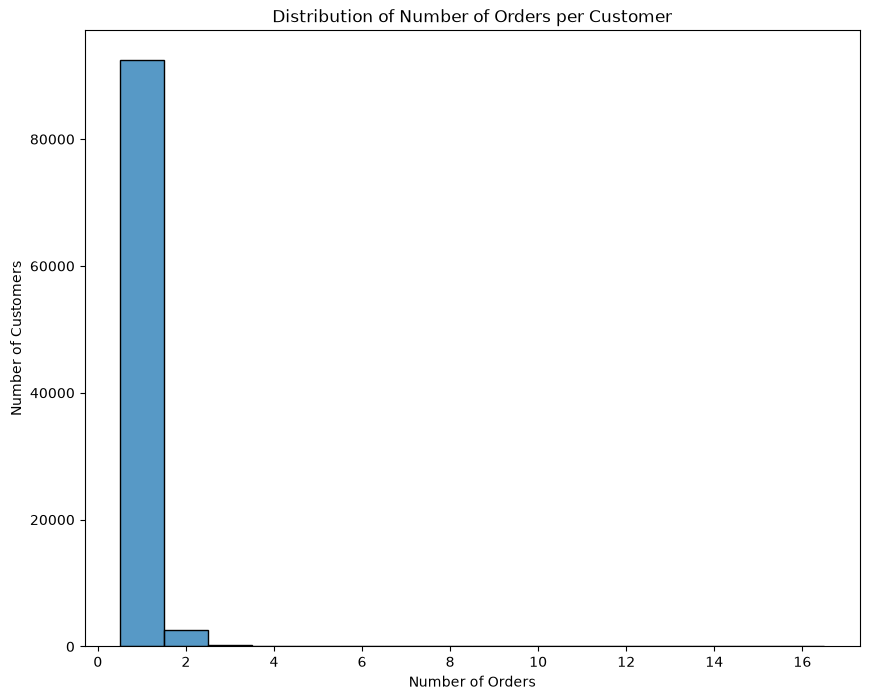

In [120]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.histplot(
    data=customers_behavior_df,
    x='num_orders',
    discrete=True,
    ax=ax
)

ax.set_title('Distribution of Number of Orders per Customer')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')

plt.show()

#### insight : the vast majority of customers make one order only

In [121]:
repeat_rate = (
    (customers_behavior_df['num_orders'] > 1).mean() * 100
)

one_time_rate = (
    (customers_behavior_df['num_orders'] == 1).mean() * 100
)

print(f"Repeat rate : {repeat_rate}")
print(f"one-time rate : {one_time_rate}")

Repeat rate : 3.0528191154894153
one-time rate : 96.94718088451059


In [122]:
rate_repeat_one_time_orders = pd.DataFrame({'repeat_rate': [repeat_rate],
                                            'one_time_rate':[one_time_rate]})
rate_repeat_one_time_orders

,repeat_rate,one_time_rate
0,3.05,96.95


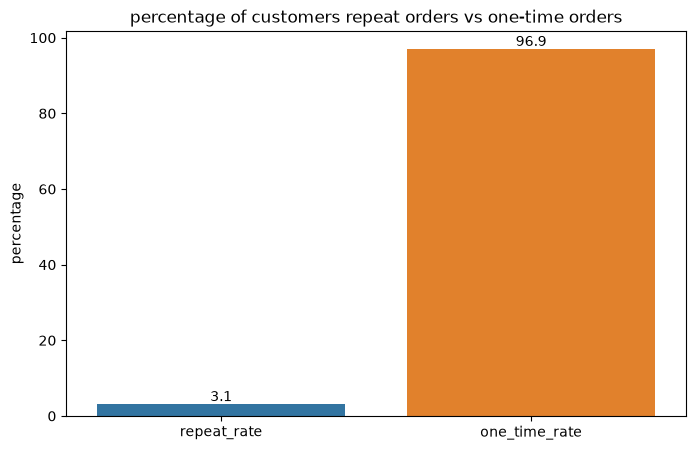

In [123]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(rate_repeat_one_time_orders,)

ax.set_title('percentage of customers repeat orders vs one-time orders')
ax.set_ylabel('percentage')

for container in ax.containers:
    ax.bar_label(container,color='black',size=10,fmt='%.1f')

In [124]:
customers_behavior_df[customers_behavior_df['num_orders'] > 1].sort_values('avg_order_value',ascending=False).head(20)

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
81388,da122df9eeddfedc1dc1f5349a1a690c,2,2,"7,388.00",183.63,RJ,1.00,"3,694.00",91.81,0.02,520,0,<NA>
2014,055ec572ac7f3c7bdd04a183830ebe59,2,2,"3,999.98",53.10,SP,1.00,"1,999.99",26.55,0.01,412,30,0.07
33622,59d66d72939bc9497e19d89c61a96d5f,2,2,"3,459.00",100.99,SP,1.00,"1,729.50",50.50,0.03,389,161,0.01
33203,58c1b085b54c03a1f1ab5f13d64c2b1c,2,2,"2,999.98",64.74,PE,1.00,"1,499.99",32.37,0.02,352,0,<NA>
80425,d77aa95864ae5b42160937615628723a,2,2,"2,400.00",50.10,BA,1.00,"1,200.00",25.05,0.02,370,0,<NA>
45973,7b0eaf68a16e4808e5388c67345033c9,2,2,"2,238.42",101.66,SP,1.00,"1,119.21",50.83,0.04,107,0,<NA>
41070,6ddbc64bd04d40f7768ff088d94cbeb8,2,2,"2,108.00",191.66,SP,1.00,"1,054.00",95.83,0.08,147,0,<NA>
74752,c8460e4251689ba205045f3ea17884a1,4,24,"4,080.00",575.88,RS,6.00,"1,020.00",143.97,0.12,26,1,4.00
43120,73601b1eec55943e90ce8d61253d5c09,2,2,"2,009.98",58.70,MG,1.00,"1,004.99",29.35,0.03,306,35,0.06
53796,906a8a4ec9f3d4c3e64fa6d1c4fe6009,2,7,"1,835.00",185.83,SP,3.50,917.50,92.91,0.09,46,15,0.13


Text(0.5, 1.0, 'distribution of average order value for each customer')

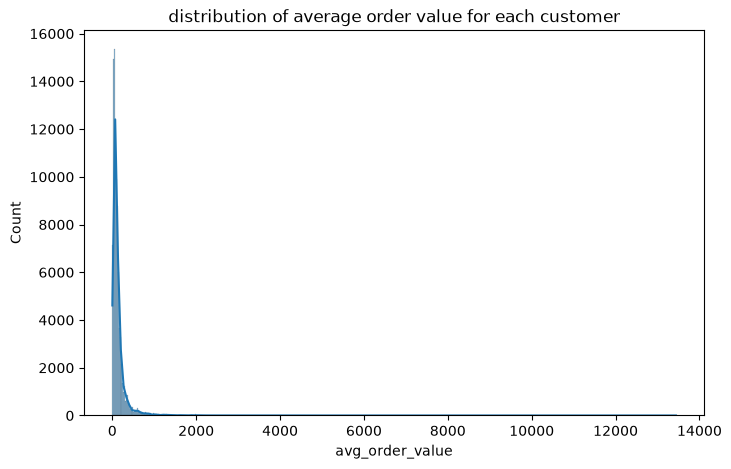

In [125]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(data=customers_behavior_df,
             x='avg_order_value',
             kde=True)

ax.set_title('distribution of average order value for each customer')

Text(0.5, 1.0, 'distribution of total price for each customer')

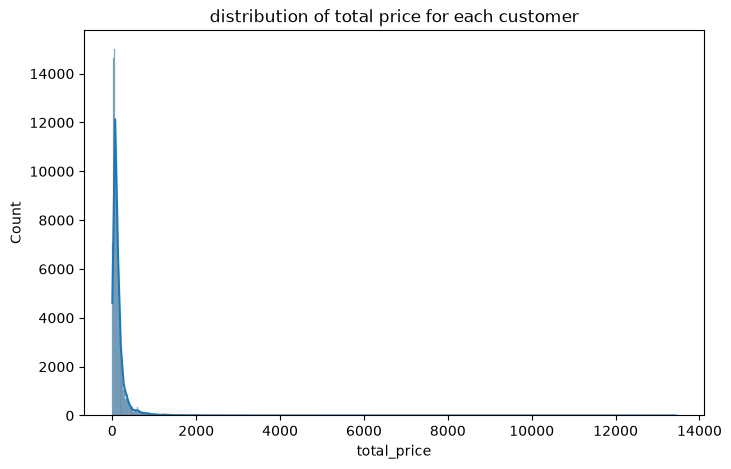

In [126]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(data=customers_behavior_df,
             x='total_price',
             kde=True)

ax.set_title('distribution of total price for each customer')

Text(0.5, 1.0, 'distribution of average total freight for each customer')

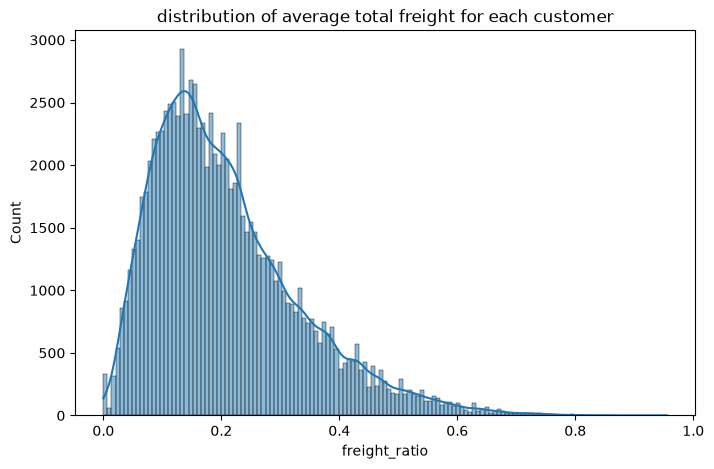

In [127]:
fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(data=customers_behavior_df,
             x='freight_ratio',
             kde=True)

ax.set_title('distribution of average total freight for each customer')

<Axes: xlabel='recency_days', ylabel='Count'>

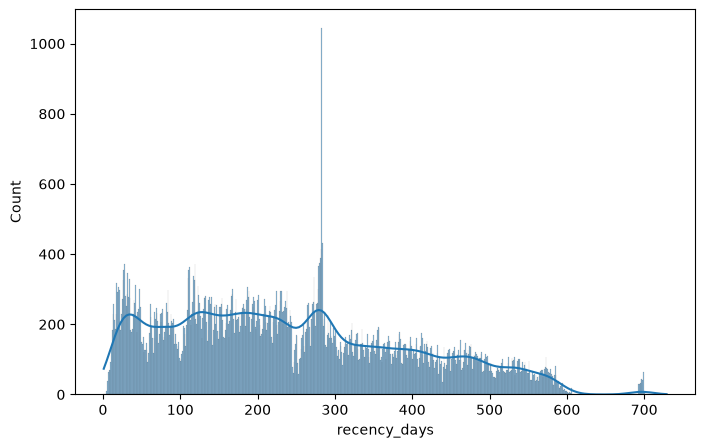

In [128]:
fig, axes = plt.subplots(figsize=(8,5))


sns.histplot(
    data=customers_behavior_df,
    x='recency_days',
    discrete=True,
    kde=True,
    ax=axes
)

In [129]:
customers_behavior_df.sort_values('avg_order_freight',ascending=False).head(20)

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
95407,fff5eb4918b2bf4b2da476788d42051c,1,6,"1,050.00","1,794.96",PB,6.00,"1,050.00","1,794.96",0.63,63,0,<NA>
2397,066ee6b9c6fc284260ff9a1274a82ca7,1,6,419.40,"1,002.29",PR,6.00,419.40,"1,002.29",0.70,440,0,<NA>
89325,ef7361e14a64f77990f58e9c571e2f9a,1,3,"1,380.00",711.33,MA,3.00,"1,380.00",711.33,0.34,190,0,<NA>
95415,fffcf5a5ff07b0908bd4e2dbc735a684,1,2,"1,570.00",497.42,PE,2.00,"1,570.00",497.42,0.24,452,0,<NA>
30814,527f7f3237fb1397c459701bc765b6f0,1,2,"1,520.00",497.08,PE,2.00,"1,520.00",497.08,0.25,480,0,<NA>
87642,eae0a83d752b1dd32697e0e7b4221656,2,15,"1,821.73",961.28,BA,7.50,910.87,480.64,0.35,132,81,0.02
40830,6d394722d5fc5e721aee6875a218d8db,1,8,"1,559.92",479.28,RJ,8.00,"1,559.92",479.28,0.24,303,0,<NA>
37413,6411590d91c48640cb07e72fbb4a359e,1,9,"1,161.00",458.73,GO,9.00,"1,161.00",458.73,0.28,168,0,<NA>
92879,f9172a6495d46451776be8bc8e46032d,1,7,859.66,456.47,RJ,7.00,859.66,456.47,0.35,154,0,<NA>
21192,3895f60f6e6a89e5cfb7b72ffdcdf7e0,1,2,"1,767.80",436.24,BA,2.00,"1,767.80",436.24,0.20,234,0,<NA>


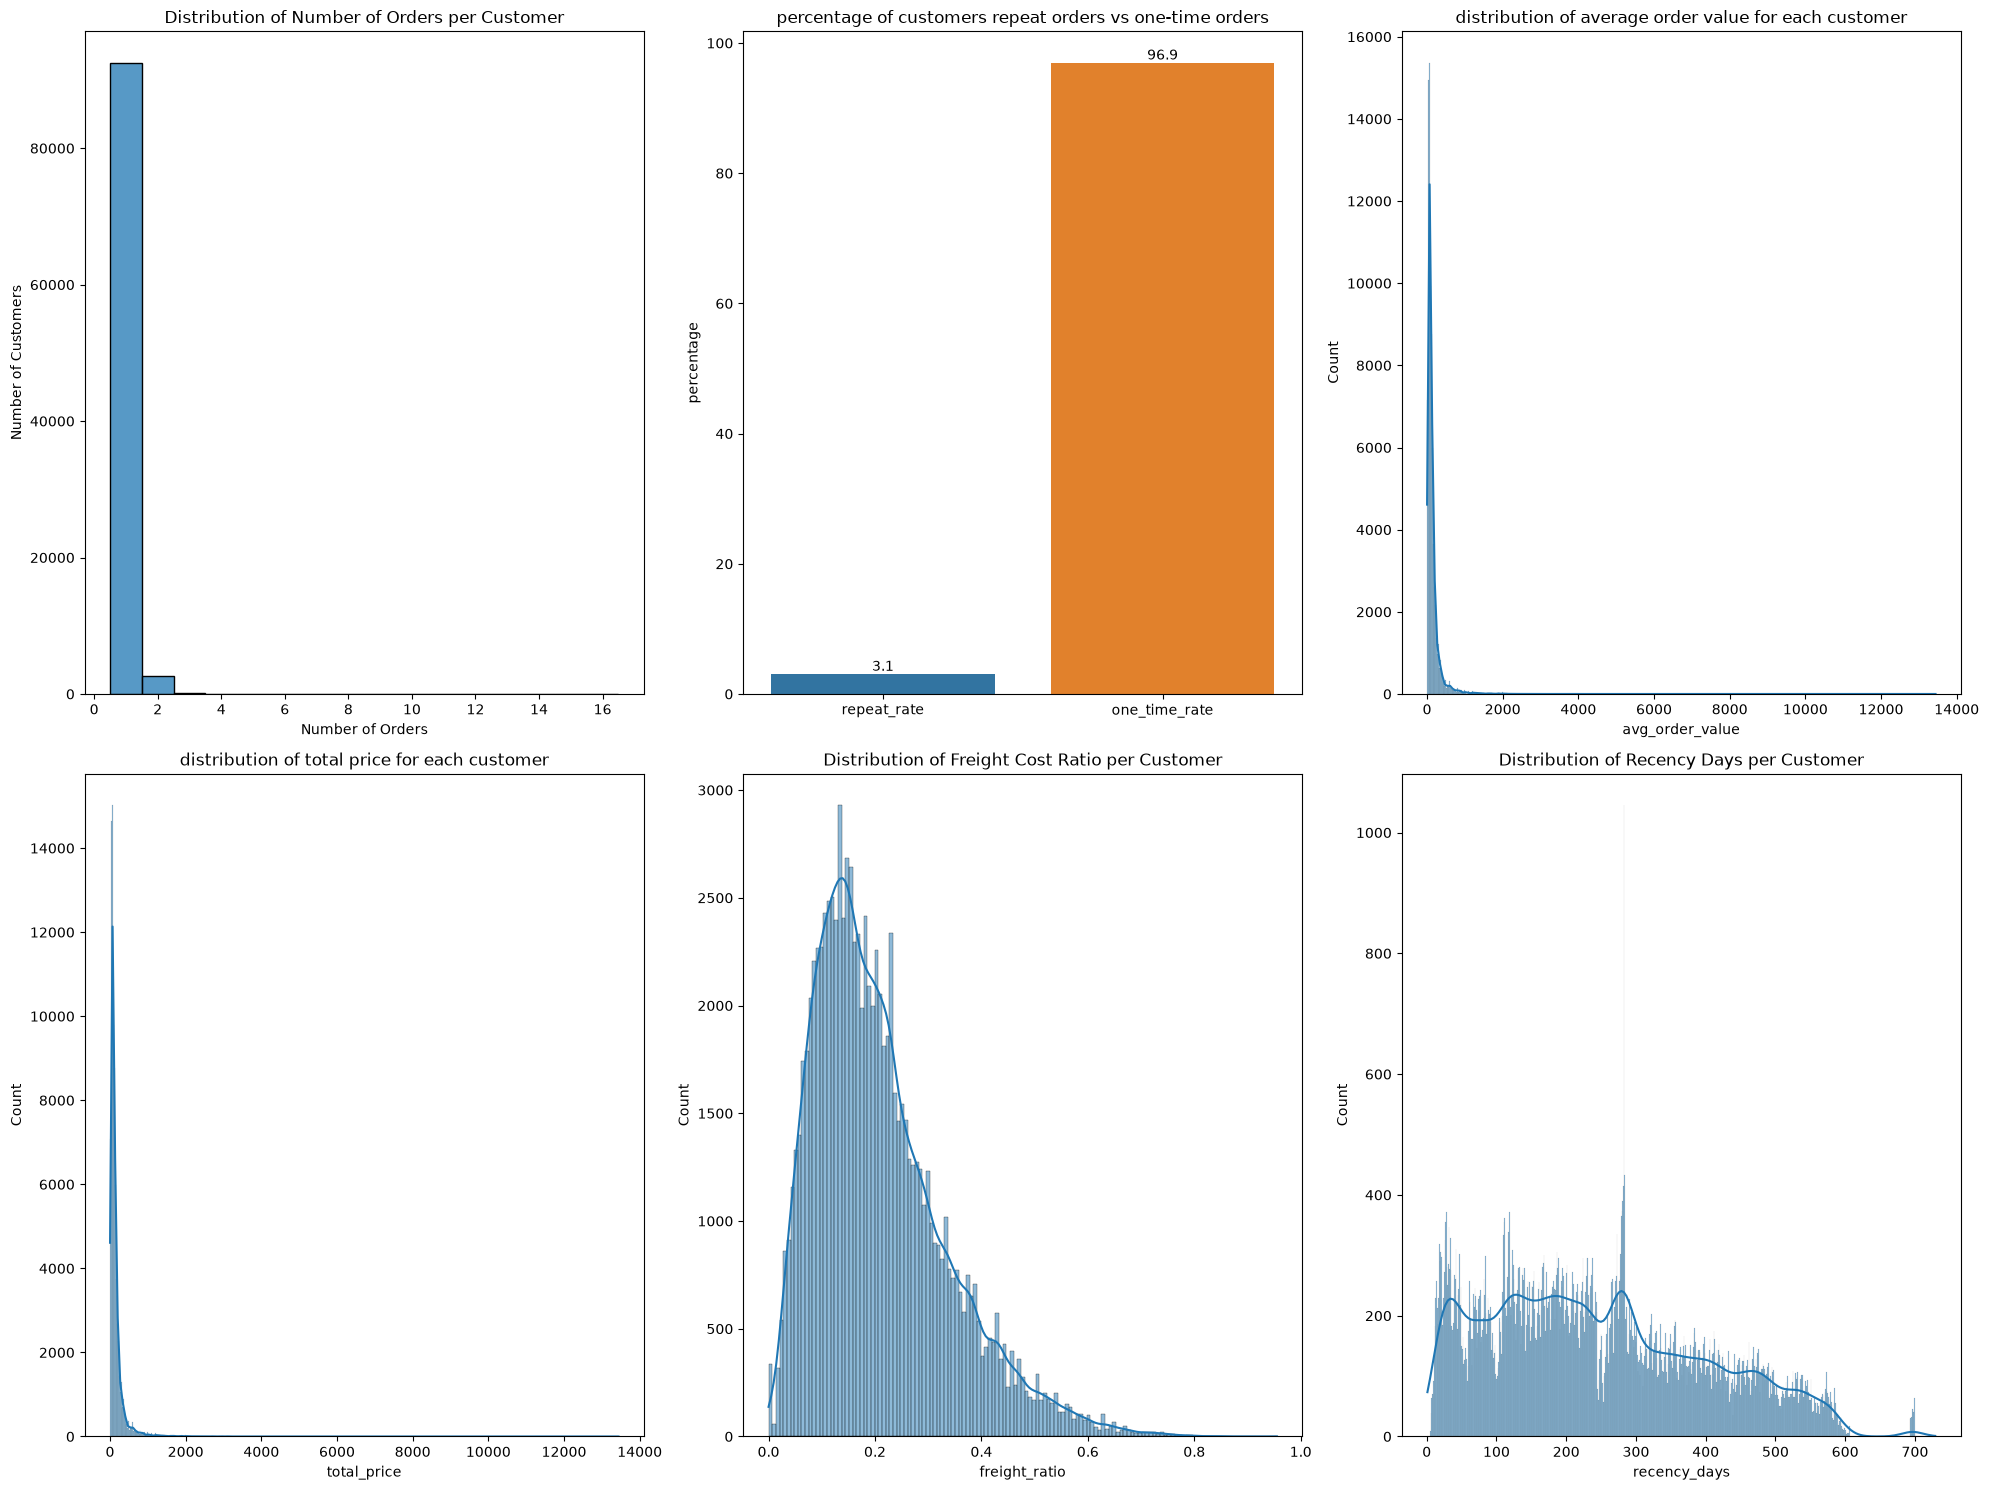

In [130]:
fig, axes = plt.subplots(2,3,figsize=(20,15))

axes = axes.flatten()

sns.histplot(
    data=customers_behavior_df,
    x='num_orders',
    discrete=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Number of Orders per Customer')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')

sns.barplot(rate_repeat_one_time_orders,
            ax=axes[1])

axes[1].set_title('percentage of customers repeat orders vs one-time orders')
axes[1].set_ylabel('percentage')

for container in axes[1].containers:
    axes[1].bar_label(container,color='black',size=10,fmt='%.1f')

sns.histplot(data=customers_behavior_df,
             x='avg_order_value',
             kde=True,
             ax=axes[2])

axes[2].set_title('distribution of average order value for each customer')

sns.histplot(data=customers_behavior_df,
             x='total_price',
             kde=True,
             ax=axes[3])

axes[3].set_title('distribution of total price for each customer')


sns.histplot(data=customers_behavior_df,
             x='freight_ratio',
             kde=True,
             ax=axes[4])

axes[4].set_title('Distribution of Freight Cost Ratio per Customer')

sns.histplot(
    data=customers_behavior_df,
    x='recency_days',
    discrete=True,
    kde=True,
    ax=axes[5]
)

axes[5].set_title('Distribution of Recency Days per Customer')

fig.tight_layout()


os.makedirs('images',exist_ok=True)

fig.savefig('./images/distributions_for_customers_behavior.png')

In [131]:
customers_behavior_df.describe()

,num_orders,num_items,total_price,total_freight,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days
count,"95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00"
mean,1.03,1.18,142.44,23.60,1.14,138.23,22.82,0.21,243.60,2.67
std,0.21,0.62,217.66,22.88,0.53,211.41,21.56,0.13,153.16,25.21
min,1.00,1.00,0.85,0.00,1.00,0.85,0.00,0.00,1.00,0.00
25%,1.00,1.00,47.90,14.08,1.00,46.40,13.89,0.12,119.00,0.00
50%,1.00,1.00,89.90,17.60,1.00,87.38,17.24,0.18,224.00,0.00
75%,1.00,1.00,155.00,25.54,1.00,149.90,24.13,0.27,353.00,0.00
max,16.00,24.00,"13,440.00","1,794.96",21.00,"13,440.00","1,794.96",0.96,729.00,633.00


In [132]:
print(customers_behavior_df['num_orders'].quantile([.25,.5,.75,.90,.95,.99]))
print(f'max : {customers_behavior_df['num_orders'].max()}')
print('-'* 100)
print(customers_behavior_df['total_price'].quantile([.25,.5,.75,.90,.95,.99,.999]))
print(f'max : {customers_behavior_df['total_price'].max()}')
print('-'* 100)
print(customers_behavior_df['total_freight'].quantile([.25,.5,.75,.90,.95,.99]))
print(f'max : {customers_behavior_df['total_freight'].max()}')

0.25   1.00
0.50   1.00
0.75   1.00
0.90   1.00
0.95   1.00
0.99   2.00
Name: num_orders, dtype: float64
max : 16
----------------------------------------------------------------------------------------------------
0.25      47.90
0.50      89.90
0.75     155.00
0.90     284.00
0.95     422.00
0.99   1,013.59
1.00   2,338.08
Name: total_price, dtype: float64
max : 13440.0
----------------------------------------------------------------------------------------------------
0.25    14.08
0.50    17.60
0.75    25.54
0.90    42.09
0.95    57.96
0.99   110.38
Name: total_freight, dtype: float64
max : 1794.96


In [133]:
customers_behavior_df.nlargest(10, 'total_price')[
    ['num_orders', 'total_price', 'total_freight']
]

,num_orders,total_price,total_freight
3799,1,"13,440.00",224.08
81388,2,"7,388.00",183.63
44139,1,"7,160.00",114.88
82230,1,"6,735.00",194.31
26015,1,"6,729.00",193.21
95131,1,"6,499.00",227.66
23947,1,"5,934.60",146.94
89056,1,"4,690.00",74.34
34820,1,"4,599.90",209.54
27242,1,"4,590.00",91.78


In [134]:
products_items_df = pd.merge(
    products_df,
    order_items_df,
    on='product_id'
)

products_items_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.00,261.00,1.00,371.00,26.00,4.00,26.00,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.00,402.00,4.00,625.00,20.00,17.00,13.00,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29


In [135]:
top_customers = customers_behavior_df[customers_behavior_df['total_price'] > 2000]

len(top_customers)

151

In [136]:
top_customers.head()

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
259,00adeda9b742746c0c66e10d00ea1b74,1,2,"2,078.50",69.90,SP,2.00,"2,078.50",69.90,0.03,300,0,<NA>
292,00c07da5ba0e07b4f248a3a373b07476,1,1,"2,258.00",46.68,BA,1.00,"2,258.00",46.68,0.02,38,0,<NA>
422,011875f0176909c5cf0b14a9138bb691,1,1,"3,999.90",17.01,SP,1.00,"3,999.90",17.01,0.00,534,0,<NA>
1039,02ccceb879088a0253e1e46e0200bdb8,1,1,"2,338.08",174.45,SP,1.00,"2,338.08",174.45,0.07,26,0,<NA>
1083,02e8a66528e84b3ca6150d9b1e03a26f,1,1,"2,110.00",48.57,RJ,1.00,"2,110.00",48.57,0.02,71,0,<NA>


In [137]:
# merge order customers, orders, order items, prodcuts
orders_customers_items_cleaned_products_df = pd.merge(
    orders_customers_items_cleaned_df,
    products_df,
    on='product_id'
)

orders_customers_items_cleaned_products_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_year,purchase_month,purchase_weekday,purchase_day,purchase_hour,purchase_month_sin,purchase_month_cos,purchase_hour_sin,purchase_hour_cos,purchase_weekday_sin,purchase_weekday_cos,is_weekend,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017,10,0,2,10,-0.87,0.50,0.50,-0.87,0.00,1.00,0,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018,7,1,24,20,-0.50,-0.87,-0.87,0.50,0.78,0.62,0,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018,8,2,8,8,-0.87,-0.50,0.87,-0.50,0.97,-0.22,0,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017,11,5,18,19,-0.50,0.87,-0.97,0.26,-0.97,-0.22,1,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018,2,1,13,21,0.87,0.50,-0.71,0.71,0.78,0.62,0,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00


In [138]:
top_customers_unique_ids = top_customers['customer_unique_id']

len(top_customers_unique_ids)

151

In [139]:
orders_customers_items_cleaned_products_df['product_category_name'].nunique()

73

In [140]:
# get top customers by customer_unique_id
orders_customers_items_cleaned_products_df[
    orders_customers_items_cleaned_products_df['customer_unique_id']
    .isin(top_customers_unique_ids)][[
        'customer_unique_id',
        'product_category_name',
        'price'
    ]].nlargest(10,columns='price')

,customer_unique_id,product_category_name,price
25071,dc4802a71eae9be1dd28f5d788ceb526,utilidades_domesticas,"6,735.00"
32077,459bef486812aa25204be022145caa62,pcs,"6,729.00"
3925,ff4159b92c40ebe40454e3e6a7c35ed6,artes,"6,499.00"
60371,da122df9eeddfedc1dc1f5349a1a690c,eletroportateis,"4,799.00"
45649,eebb5dda148d3893cdaf5b5ca3040ccb,eletroportateis,"4,690.00"
45664,48e1ac109decbb87765a3eade6854098,pcs,"4,590.00"
13141,edde2314c6c30e864a128ac95d6b2112,instrumentos_musicais,"4,399.87"
22007,fa562ef24d41361e476e748681810e1e,consoles_games,"4,099.99"
3024,ca27f3dac28fb1063faddd424c9d95fa,esporte_lazer,"4,059.00"
64534,011875f0176909c5cf0b14a9138bb691,relogios_presentes,"3,999.90"


In [141]:
orders_customers_items_cleaned_products_df[orders_customers_items_cleaned_products_df['customer_unique_id'] == '0a0a92112bd4c708ca5fde585afaa872']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_year,purchase_month,purchase_weekday,purchase_day,purchase_hour,purchase_month_sin,purchase_month_cos,purchase_hour_sin,purchase_hour_cos,purchase_weekday_sin,purchase_weekday_cos,is_weekend,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
15070,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,1,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15071,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,2,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15072,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,3,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15073,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,4,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15074,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,5,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15075,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,6,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15076,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a92112bd4c708ca5fde585afaa872,20080,rio de janeiro,RJ,7,5769ef0a239114ac3a854af00df129e4,b37c4c02bda3161a7546a4e6d222d5b2,2017-10-06 15:28:20,"1,680.00",28.01,2017,9,4,29,15,-1.00,-0.00,-0.71,-0.71,-0.43,-0.90,0,telefonia_fixa,39.00,"2,493.00",3.00,750.00,16.00,16.00,16.00
15077,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,delivered,2017-09-29 15:24:52,2017-10-02 15:28:20,2017-10-10 15:43:17,2017-10-17 18:22:29,2017-10-23,0a0a

### Duplicates

In [142]:
orders_customers_items_cleaned_products_copy_df = orders_customers_items_cleaned_products_df.copy()

orders_customers_items_cleaned_products_copy_df.drop('order_item_id',axis=1)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_year,purchase_month,purchase_weekday,purchase_day,purchase_hour,purchase_month_sin,purchase_month_cos,purchase_hour_sin,purchase_hour_cos,purchase_weekday_sin,purchase_weekday_cos,is_weekend,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2017,10,0,2,10,-0.87,0.50,0.50,-0.87,0.00,1.00,0,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,2018,7,1,24,20,-0.50,-0.87,-0.87,0.50,0.78,0.62,0,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,2018,8,2,8,8,-0.87,-0.50,0.87,-0.50,0.97,-0.22,0,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,2017,11,5,18,19,-0.50,0.87,-0.97,0.26,-0.97,-0.22,1,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,2018,2,1,13,21,0.87,0.50,-0.71,0.71,0.78,0.62,0,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10,2018,2,1,6,12,0.87,0.50,0.00,-1.00,0.78,0.62,0,bebes,52.00,828.00,4.00,"4,950.00",40.00,10.00,40.00
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02,2017,8,6,27,14,-0.87,-0.50,-0.50,-0.87,-0.78,0.62,1,eletrodomesticos_2,51.00,500.00,2.00,"13,300.00",32.00,90.00,22.00
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,5097a5

In [143]:
orders_customers_items_cleaned_products_copy_df.duplicated().sum()

np.int64(0)

In [144]:
orders_customers_items_cleaned_products_copy_df.duplicated(
    subset=['order_id','customer_unique_id','product_id'],
    keep=False
).sum()

np.int64(17313)

In [145]:
dups = orders_customers_items_cleaned_products_copy_df[
    orders_customers_items_cleaned_products_copy_df.duplicated(
        subset=['order_id', 'customer_id', 'product_id'],
        keep=False
    )
].sort_values(['order_id', 'product_id'])

dups.head(20)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,purchase_year,purchase_month,purchase_weekday,purchase_day,purchase_hour,purchase_month_sin,purchase_month_cos,purchase_hour_sin,purchase_hour_cos,purchase_weekday_sin,purchase_weekday_cos,is_weekend,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
61067,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13 22:10:21,2018-02-15 03:55:52,2018-02-20 18:23:28,2018-02-26 13:55:22,2018-03-06,9e4159995424971423b98c4a8bc11529,6600,jandira,SP,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37,2018,2,1,13,22,0.87,0.50,-0.50,0.87,0.78,0.62,0,ferramentas_jardim,57.00,366.00,2.00,"1,650.00",30.00,22.00,30.00
61068,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,delivered,2018-02-13 22:10:21,2018-02-15 03:55:52,2018-02-20 18:23:28,2018-02-26 13:55:22,2018-03-06,9e4159995424971423b98c4a8bc11529,6600,jandira,SP,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37,2018,2,1,13,22,0.87,0.50,-0.50,0.87,0.78,0.62,0,ferramentas_jardim,57.00,366.00,2.00,"1,650.00",30.00,22.00,30.00
41054,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06,bb8a37225e0279ac8a274c9765617eaf,74663,goiania,GO,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10,2017,10,0,16,15,-0.87,0.50,-0.71,-0.71,0.00,1.00,0,esporte_lazer,52.00,"1,153.00",1.00,180.00,17.00,11.00,14.00
41055,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06,bb8a37225e0279ac8a274c9765617eaf,74663,goiania,GO,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10,2017,10,0,16,15,-0.87,0.50,-0.71,-0.71,0.00,1.00,0,esporte_lazer,52.00,"1,153.00",1.00,180.00,17.00,11.00,14.00
41056,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06,bb8a37225e0279ac8a274c9765617eaf,74663,goiania,GO,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10,2017,10,0,16,15,-0.87,0.50,-0.71,-0.71,0.00,1.00,0,esporte_lazer,52.00,"1,153.00",1.00,180.00,17.00,11.00,14.00
30529,001ab0a7578dd66cd4b0a71f5b6e1e41,8bb3bef4e75a95524235cdc11a7331af,delivered,2017-12-27 00:38:47,2017-12-28 02:33:42,2017-12-28 18:09:35,2018-01-17 20:43:29,2018-01-29,d1f24d1d504e27bee13b415e40daeab0,40055,salvador,BA,1,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63,2017,12,2,27,0,-0.00,1.00,0.00,1.00,0.97,-0.22,0,eletronicos,53.00,265.00,2.00,150.00,22.00,13.00,15.00
30530,001ab0a7578dd66cd4b0a71f5b6e1e41,8bb3bef4e75a95524235cdc11a7331af,delivered,2017-12-27 00:38:47,2017-12-28 02:33:42,2017-12-28 18:09:35,2018-01-17 20:43:29,2018-01-29,d1f24d1d504e27bee13b415e40daeab0,40055,salvador,BA,2,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,2018-01-04 02:33:42,24.89,17.63,2017,12,2,27,0,-0.00,1.00,0.00,1.00,0.97,-0.22,0,eletronicos,53.00,265.00,2.00,150.00,22.00,13.00,15.00
30531,001ab0a7578dd66cd4b0a71f5b6e1e41,8bb3bef4e75a95524235cdc11a7331af,delivered,2017-12-27 00:38:47,2017-12-28 02:33:42,2017-12-28 18:09:35,2018-01-17 20:43:29,2018-01-29,d1f24d1d504e27bee13b415e40daeab0,40055,salvador,BA,3,0b0172eb0fd18479d29c3bc122c058c2,5656537e588803a555b8eb41f07a944b,20

In [146]:
dups.groupby(
    ['order_id', 'customer_id', 'product_id']
).size().value_counts().sort_index()

2     5382
3      953
4      390
5      168
6      172
7        4
8        2
9        2
10       5
11       1
12       2
13       1
14       2
15       2
20       2
Name: count, dtype: int64

In [147]:
orders_customers_items_cleaned_df.duplicated(
    subset=[
        'order_id',
        'customer_unique_id',
        'product_id',
        'price'
    ],
    keep=False
).sum()

np.int64(17313)

In [148]:
# orders_customers_items_cleaned_df.drop_duplicates(subset=[
#     'order_id',
#     'customer_unique_id',
#     'product_id',
#     'price'
# ],  
# inplace=True)

In [149]:
orders_customers_items_cleaned_df.duplicated(
    subset=[
        'order_id',
        'customer_unique_id',
        'product_id',
        'price'
    ],
    keep=False
).sum()

np.int64(17313)

In [150]:
customer_id = top_customers.loc[
    top_customers['total_price'].idxmax(),
    'customer_unique_id'
]

customer_data = orders_customers_items_cleaned_products_copy_df[
    orders_customers_items_cleaned_products_copy_df['customer_unique_id'] == customer_id
]

customer_data[
    ['order_id', 'customer_id', 'product_id', 'price']
]

,order_id,customer_id,product_id,price
15070,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15071,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15072,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15073,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15074,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15075,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15076,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"
15077,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,5769ef0a239114ac3a854af00df129e4,"1,680.00"


In [151]:
customer_data.groupby(
    ['order_id', 'product_id']
).agg(
    count=('product_id', 'size'),
    price_sum=('price', 'sum')
).sort_values('count', ascending=False).reset_index()

,order_id,product_id,count,price_sum
0,03caa2c082116e1d31e67e9ae3700499,5769ef0a239114ac3a854af00df129e4,8,"13,440.00"


In [152]:
products_items_df.groupby([
    'order_id','product_id'
]).size().value_counts()

1     95337
2      5382
3       953
4       390
6       172
5       168
10        5
7         4
8         2
20        2
12        2
15        2
14        2
9         2
13        1
11        1
Name: count, dtype: int64

In [153]:
num_customers_per_state = (
    customers_behavior_df
    .groupby('state')
    .agg(
        num_customers=('customer_unique_id', 'nunique'),
        num_orders=('num_orders','sum'),
        total_price=('total_price','sum'),
        total_freight=('total_freight','sum'))

).reset_index()

num_customers_per_state.sort_values('num_customers',ascending=False).head()

,state,num_customers,num_orders,total_price,total_freight
25,SP,39975,41382,"5,204,295.35","719,146.85"
18,RJ,12299,12761,"1,823,944.89","305,561.82"
10,MG,11173,11543,"1,585,318.90","270,790.17"
22,RS,5248,5432,"750,384.02","135,526.80"
17,PR,4839,5000,"683,178.56","117,878.60"


In [154]:
num_customers_per_state['percentage_customers'] = (
    num_customers_per_state['num_customers']
    / num_customers_per_state['num_customers'].sum()
    * 100
)

num_customers_per_state['percentage_orders'] = (
    num_customers_per_state['num_orders']
    / num_customers_per_state['num_orders'].sum()
    * 100
)

num_customers_per_state['percentage_revenue'] = (
    num_customers_per_state['total_price']
    / num_customers_per_state['total_price'].sum()
    * 100
)

num_customers_per_state['revenue_per_customer'] = (
    num_customers_per_state['total_price']
    / num_customers_per_state['num_customers']
)

num_customers_per_state['avg_order_value'] = (
    num_customers_per_state['total_price']
    / num_customers_per_state['num_orders']
)

num_customers_per_state.sort_values(
    'num_customers',
    ascending=False
).head()

,state,num_customers,num_orders,total_price,total_freight,percentage_customers,percentage_orders,percentage_revenue,revenue_per_customer,avg_order_value
25,SP,39975,41382,"5,204,295.35","719,146.85",41.89,41.94,38.29,130.19,125.76
18,RJ,12299,12761,"1,823,944.89","305,561.82",12.89,12.93,13.42,148.30,142.93
10,MG,11173,11543,"1,585,318.90","270,790.17",11.71,11.70,11.66,141.89,137.34
22,RS,5248,5432,"750,384.02","135,526.80",5.50,5.51,5.52,142.98,138.14
17,PR,4839,5000,"683,178.56","117,878.60",5.07,5.07,5.03,141.18,136.64


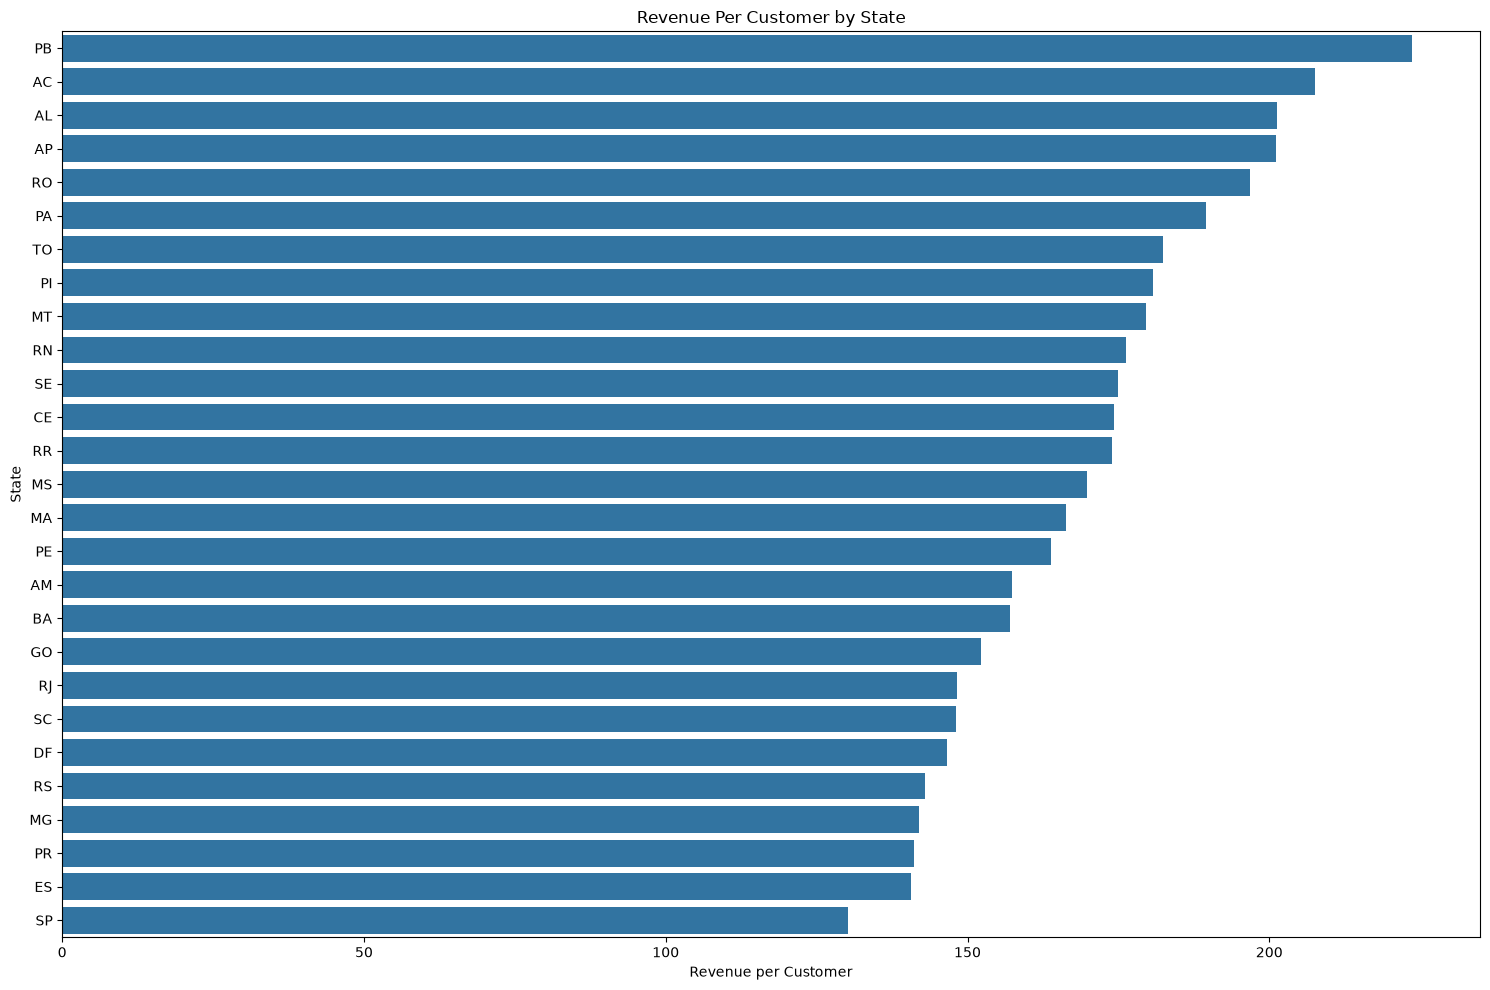

In [155]:
state_revenue = num_customers_per_state.sort_values(
    'revenue_per_customer',
    ascending=False
)

fig, ax = plt.subplots(figsize=(15, 10))

sns.barplot(
    data=state_revenue,
    x='revenue_per_customer',
    y='state',
    ax=ax
)

ax.set_title("Revenue Per Customer by State")
ax.set_xlabel("Revenue per Customer")
ax.set_ylabel("State")

plt.tight_layout()

# --------------------------------------------------------------------------

# -----------------------------------------------------------

In [156]:
num_customers_per_state['revenue_per_customer'].min(), num_customers_per_state['revenue_per_customer'].max()

(np.float64(130.1887517198249), np.float64(223.72425242718447))

In [157]:
state_customer_behavior = (
    customers_behavior_df
    .groupby('state')
    .agg(
        num_customers=('customer_unique_id','nunique'),
        num_one_time_customers=('num_orders', lambda x: (x == 1).sum()),
        num_repeat_customers=('num_orders', lambda x: (x > 1).sum())
    )
).reset_index()

state_customer_behavior.head()

,state,num_customers,num_one_time_customers,num_repeat_customers
0,AC,77,73,4
1,AL,399,387,12
2,AM,142,139,3
3,AP,67,66,1
4,BA,3257,3164,93


In [158]:
state_customer_behavior['one_time_rate'] = (
    state_customer_behavior['num_one_time_customers']
    / state_customer_behavior['num_customers'] * 100 
)

state_customer_behavior['repeat_rate'] = (
    state_customer_behavior['num_repeat_customers']
    / state_customer_behavior['num_customers'] * 100
)

state_customer_behavior.sort_values('one_time_rate',ascending=True).head()

,state,num_customers,num_one_time_customers,num_repeat_customers,one_time_rate,repeat_rate
0,AC,77,73,4,94.81,5.19
20,RO,234,225,9,96.15,3.85
18,RJ,12299,11883,416,96.62,3.38
12,MT,872,843,29,96.67,3.33
8,GO,1941,1879,62,96.81,3.19


In [159]:
print(f'min one time rate : {state_customer_behavior['one_time_rate'].min()}')
print(f'max one time rate : {state_customer_behavior['one_time_rate'].max()}')
print('-' * 100)
print(f'min repeat rate : {state_customer_behavior['repeat_rate'].min()}')
print(f'max repeat rate : {state_customer_behavior['repeat_rate'].max()}')

min one time rate : 94.8051948051948
max one time rate : 98.50746268656717
----------------------------------------------------------------------------------------------------
min repeat rate : 1.4925373134328357
max repeat rate : 5.194805194805195


<Axes: xlabel='state', ylabel='num_one_time_customers'>

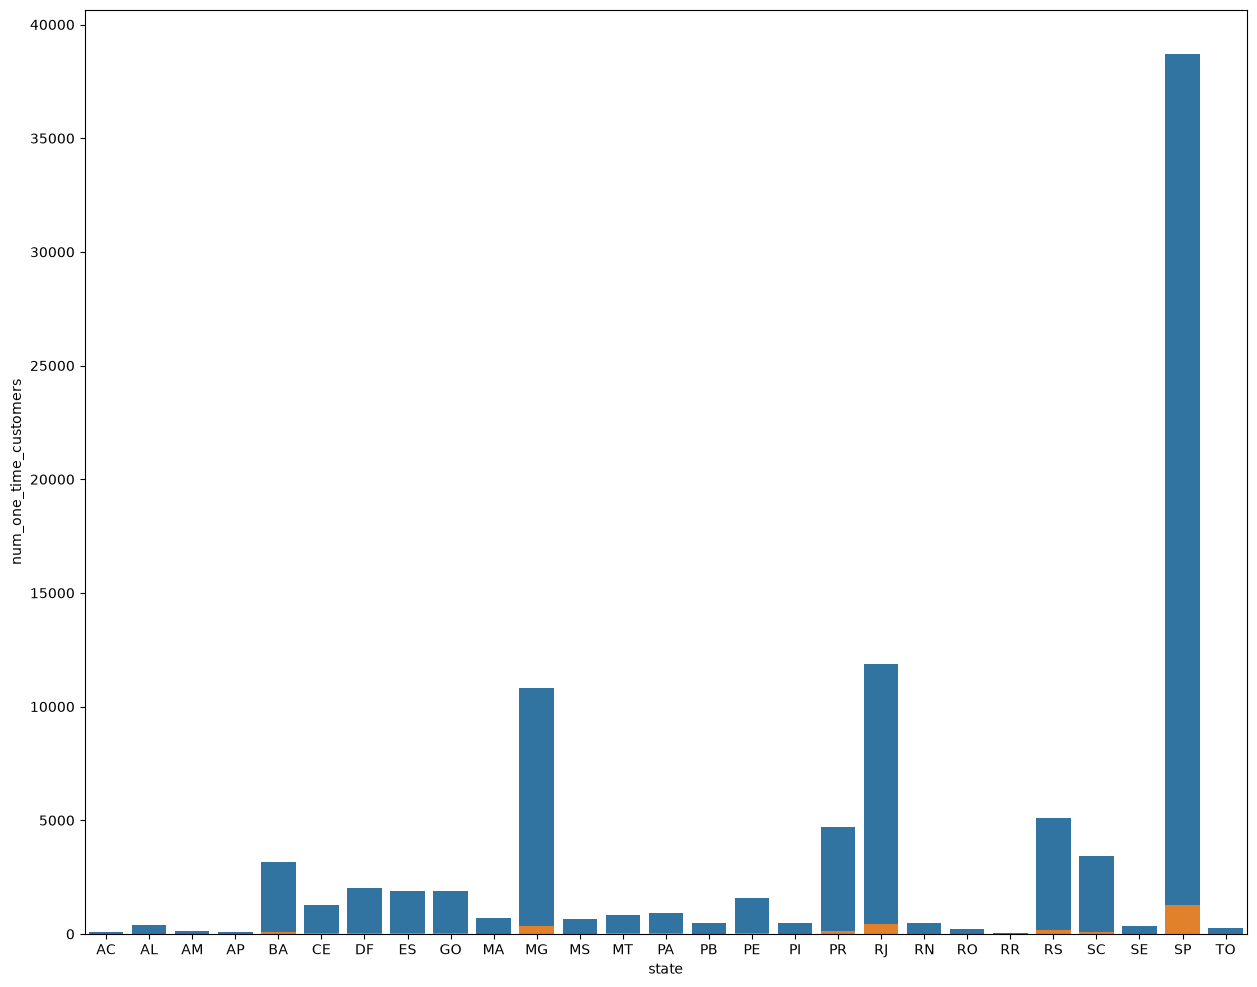

In [160]:
fig,ax = plt.subplots(figsize=(15,12))

sns.barplot(data=state_customer_behavior,
            x='state',
            y='num_one_time_customers',
            ax=ax)

sns.barplot(data=state_customer_behavior,
            x='state',
            y='num_repeat_customers',
            ax=ax)

In [161]:
customers_behavior_df['repeate_customer'] = (
    customers_behavior_df['num_orders'] > 1
).astype(int)

customers_behavior_df.head()

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,129.90,12.00,SP,1.00,129.90,12.00,0.08,116,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,18.90,8.29,SP,1.00,18.90,8.29,0.30,119,0,0
2,0000f46a3911fa3c0805444483337064,1,1,69.00,17.22,SC,1.00,69.00,17.22,0.20,542,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,25.99,17.63,PA,1.00,25.99,17.63,0.40,326,0,0
4,0004aac84e0df4da2b147fca70cf8255,1,1,180.00,16.89,SP,1.00,180.00,16.89,0.09,293,0,0


In [162]:
customers_behavior_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_unique_id    95420 non-null  str    
 1   num_orders            95420 non-null  int64  
 2   num_items             95420 non-null  int64  
 3   total_price           95420 non-null  float64
 4   total_freight         95420 non-null  float64
 5   state                 95420 non-null  str    
 6   avg_items_per_orders  95420 non-null  float64
 7   avg_order_value       95420 non-null  float64
 8   avg_order_freight     95420 non-null  float64
 9   freight_ratio         95420 non-null  float64
 10  recency_days          95420 non-null  int64  
 11  purchase_span_days    95420 non-null  int64  
 12  repeate_customer      95420 non-null  int64  
dtypes: float64(6), int64(5), str(2)
memory usage: 9.5 MB


In [163]:
numerical_customre_behavior_features_df = customers_behavior_df.copy()

numerical_customre_behavior_features_df.drop(['customer_unique_id',
                                              'state'],
                                              axis=1,
                                              inplace=True)

numerical_customre_behavior_features_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_orders            95420 non-null  int64  
 1   num_items             95420 non-null  int64  
 2   total_price           95420 non-null  float64
 3   total_freight         95420 non-null  float64
 4   avg_items_per_orders  95420 non-null  float64
 5   avg_order_value       95420 non-null  float64
 6   avg_order_freight     95420 non-null  float64
 7   freight_ratio         95420 non-null  float64
 8   recency_days          95420 non-null  int64  
 9   purchase_span_days    95420 non-null  int64  
 10  repeate_customer      95420 non-null  int64  
dtypes: float64(6), int64(5)
memory usage: 8.0 MB


###### num_orders <-> repeate_customers = 0.91 : repeate_customers = 0 if num_orders is equal 1 else equal 1
###### the relationship between num_orders and repeate_customers is mathematical relation
###### -----------------------------------------------------------------------------------
###### num_items <-> avg_items_per_order = 0.38 is not strong
###### there are another features affect in average order freight
###### -----------------------------------------------------------------------------------
###### there are relatoin between variables because the calculation way
######  . num_items <-> avg_items_per_order
######  . total_price <-> avg_order_value
######  . total_freight <-> avg_order_freight
######  . num_orders <-> repeat_customers
###### -----------------------------------------------------------------------------------

###### -----------------------------------------------------------------------------------

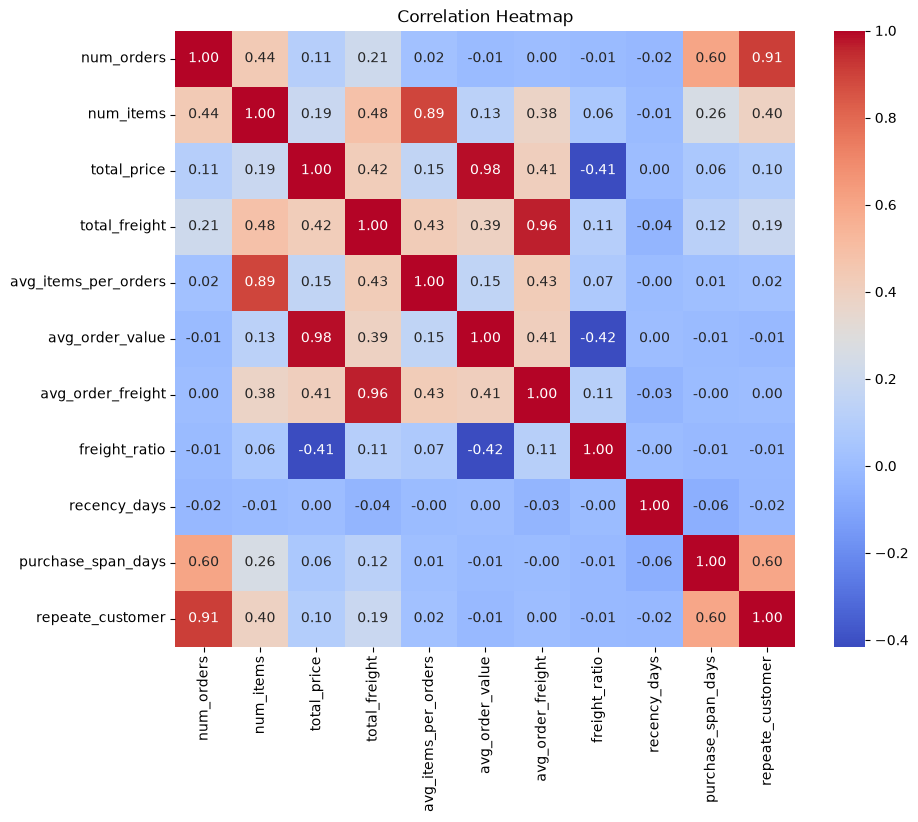

In [164]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    numerical_customre_behavior_features_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

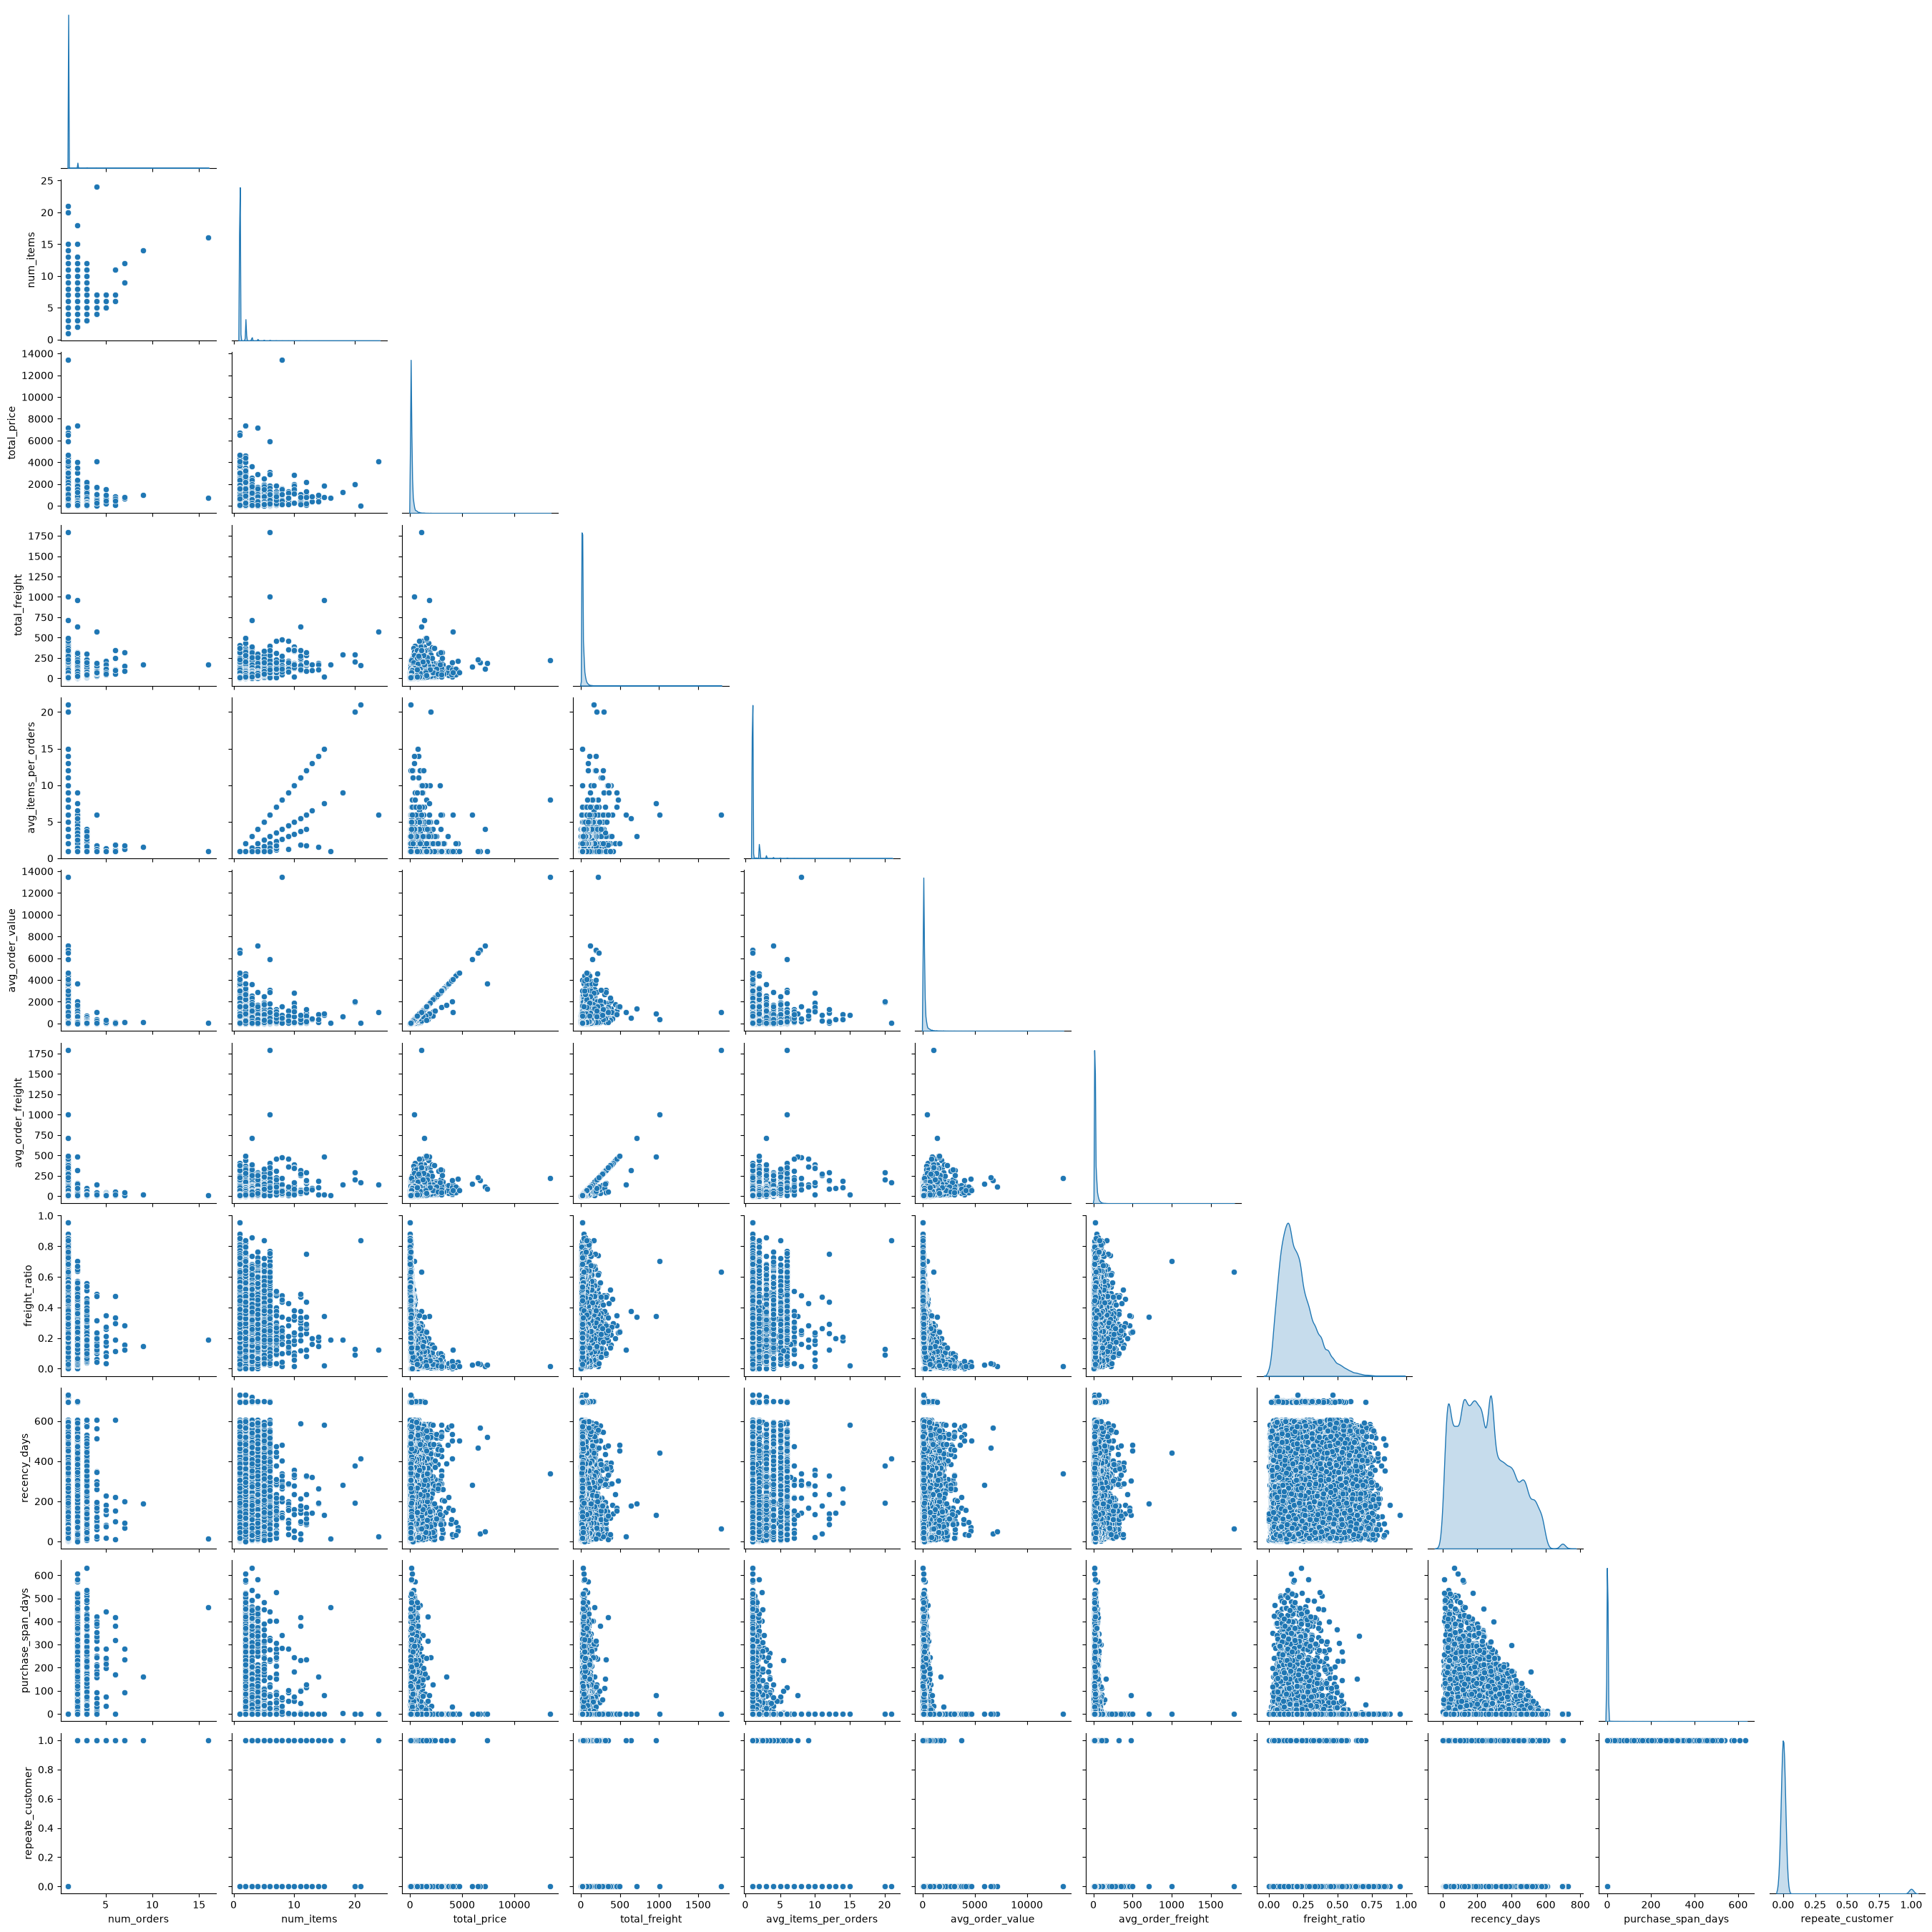

In [165]:
sns.pairplot(data=numerical_customre_behavior_features_df,
             palette='husl',
             diag_kind='kde',
             corner=True)

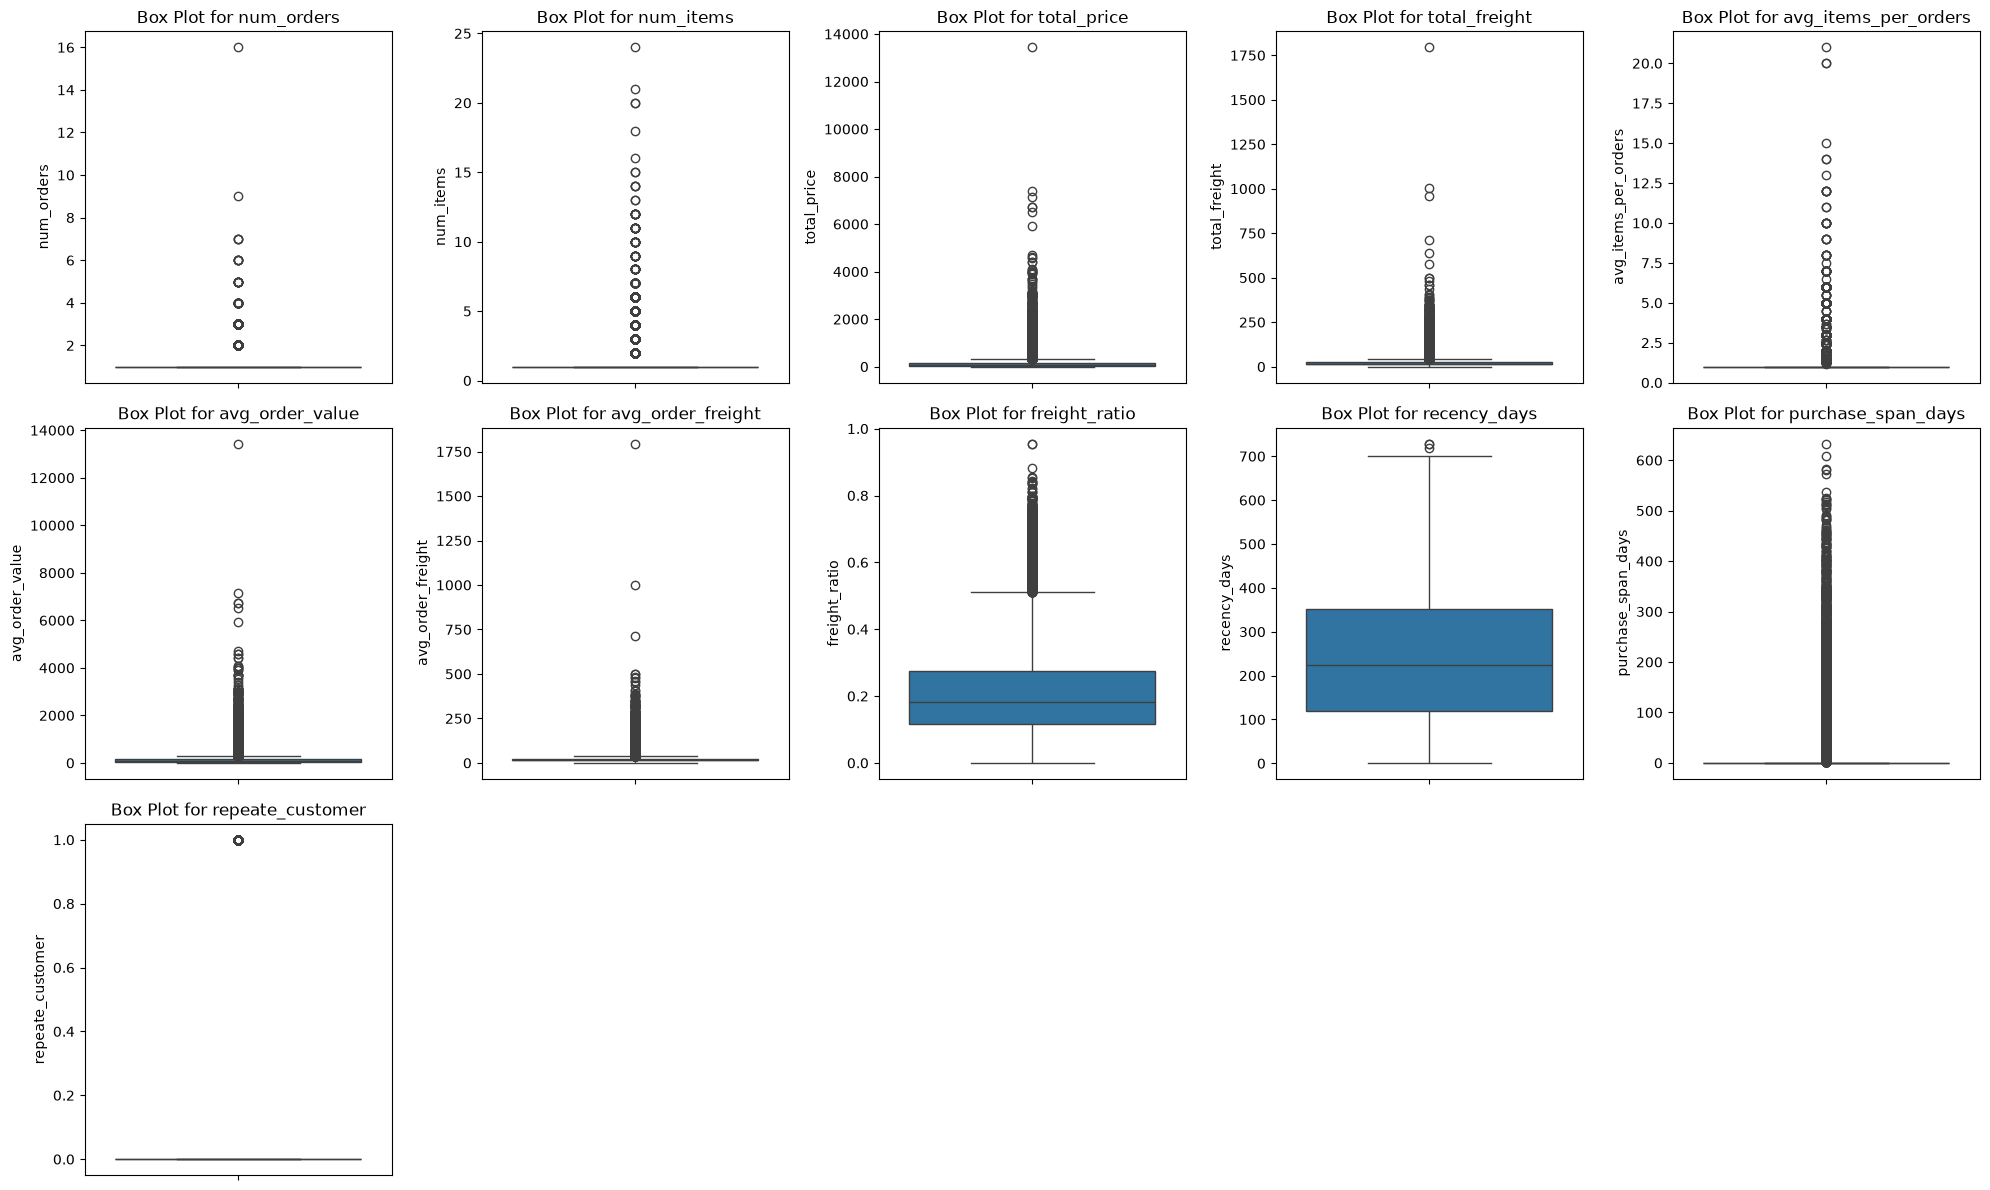

In [166]:
n_cols = 5
n_rows = int(np.ceil(len(numerical_customre_behavior_features_df.columns) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(numerical_customre_behavior_features_df.columns):
    sns.boxplot(
        data=numerical_customre_behavior_features_df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# إخفاء الـaxes الزائدة
for i in range(len(numerical_customre_behavior_features_df.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

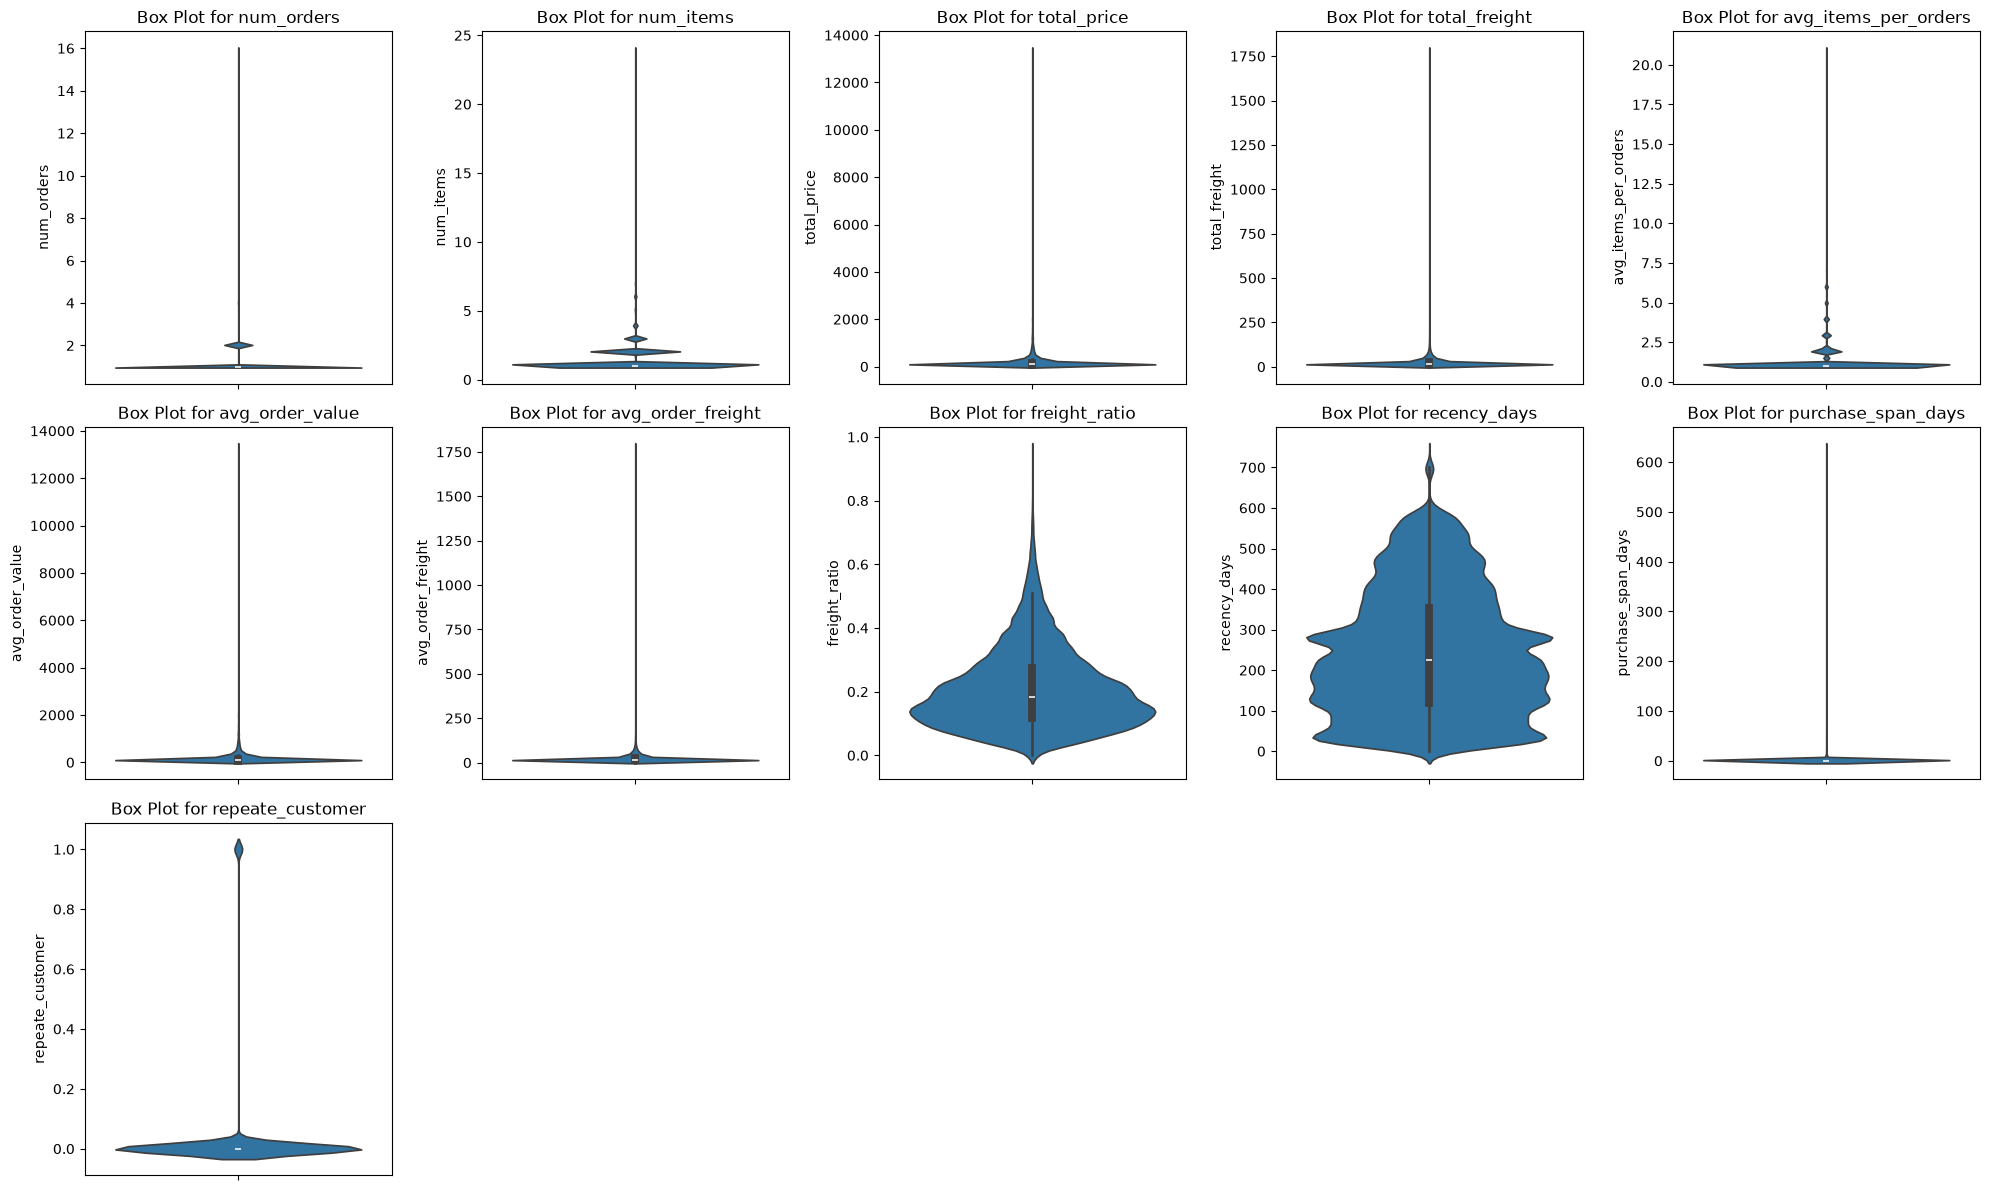

In [167]:
n_cols = 5
n_rows = int(np.ceil(len(numerical_customre_behavior_features_df.columns) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(numerical_customre_behavior_features_df.columns):
    sns.violinplot(
        data=numerical_customre_behavior_features_df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# إخفاء الـaxes الزائدة
for i in range(len(numerical_customre_behavior_features_df.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [168]:
customers_behavior_df.sort_values('total_price',ascending=False).head(10)

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
3799,0a0a92112bd4c708ca5fde585afaa872,1,8,"13,440.00",224.08,RJ,8.00,"13,440.00",224.08,0.02,339,0,0
81388,da122df9eeddfedc1dc1f5349a1a690c,2,2,"7,388.00",183.63,RJ,1.00,"3,694.00",91.81,0.02,520,0,1
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,4,"7,160.00",114.88,ES,4.00,"7,160.00",114.88,0.02,50,0,0
82230,dc4802a71eae9be1dd28f5d788ceb526,1,1,"6,735.00",194.31,MS,1.00,"6,735.00",194.31,0.03,568,0,0
26015,459bef486812aa25204be022145caa62,1,1,"6,729.00",193.21,ES,1.00,"6,729.00",193.21,0.03,40,0,0
95131,ff4159b92c40ebe40454e3e6a7c35ed6,1,1,"6,499.00",227.66,SP,1.00,"6,499.00",227.66,0.03,467,0,0
23947,4007669dec559734d6f53e029e360987,1,6,"5,934.60",146.94,MG,6.00,"5,934.60",146.94,0.02,283,0,0
89056,eebb5dda148d3893cdaf5b5ca3040ccb,1,1,"4,690.00",74.34,SP,1.00,"4,690.00",74.34,0.02,503,0,0
34820,5d0a2980b292d049061542014e8960bf,1,2,"4,599.90",209.54,GO,2.00,"4,599.90",209.54,0.04,53,0,0
27242,48e1ac109decbb87765a3eade6854098,1,1,"4,590.00",91.78,PB,1.00,"4,590.00",91.78,0.02,73,0,0


In [169]:
orders_customers_items_cleaned_df[orders_customers_items_cleaned_df['customer_unique_id'] == 'da122df9eeddfedc1dc1f5349a1a690c'][[
    'customer_unique_id',
    'price'
]]

,customer_unique_id,price
39577,da122df9eeddfedc1dc1f5349a1a690c,"2,589.00"
60371,da122df9eeddfedc1dc1f5349a1a690c,"4,799.00"


## 4. Feature Engineering

In [170]:
customers_behavior_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_unique_id    95420 non-null  str    
 1   num_orders            95420 non-null  int64  
 2   num_items             95420 non-null  int64  
 3   total_price           95420 non-null  float64
 4   total_freight         95420 non-null  float64
 5   state                 95420 non-null  str    
 6   avg_items_per_orders  95420 non-null  float64
 7   avg_order_value       95420 non-null  float64
 8   avg_order_freight     95420 non-null  float64
 9   freight_ratio         95420 non-null  float64
 10  recency_days          95420 non-null  int64  
 11  purchase_span_days    95420 non-null  int64  
 12  repeate_customer      95420 non-null  int64  
dtypes: float64(6), int64(5), str(2)
memory usage: 9.5 MB


In [171]:
customers_behavior_cleaned_df = customers_behavior_df.copy()
customers_behavior_cleaned_df = customers_behavior_cleaned_df.drop(['total_price','total_freight','repeate_customer'],axis=1)

In [172]:
customers_behavior_cleaned_df.head()

,customer_unique_id,num_orders,num_items,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1,SP,1.00,129.90,12.00,0.08,116,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1,SP,1.00,18.90,8.29,0.30,119,0
2,0000f46a3911fa3c0805444483337064,1,1,SC,1.00,69.00,17.22,0.20,542,0
3,0000f6ccb0745a6a4b88665a16c9f078,1,1,PA,1.00,25.99,17.63,0.40,326,0
4,0004aac84e0df4da2b147fca70cf8255,1,1,SP,1.00,180.00,16.89,0.09,293,0


In [173]:
numeric_customers_behavior_cleaned_df = customers_behavior_cleaned_df.select_dtypes(exclude='str')

numeric_customers_behavior_cleaned_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   num_orders            95420 non-null  int64  
 1   num_items             95420 non-null  int64  
 2   avg_items_per_orders  95420 non-null  float64
 3   avg_order_value       95420 non-null  float64
 4   avg_order_freight     95420 non-null  float64
 5   freight_ratio         95420 non-null  float64
 6   recency_days          95420 non-null  int64  
 7   purchase_span_days    95420 non-null  int64  
dtypes: float64(4), int64(4)
memory usage: 5.8 MB


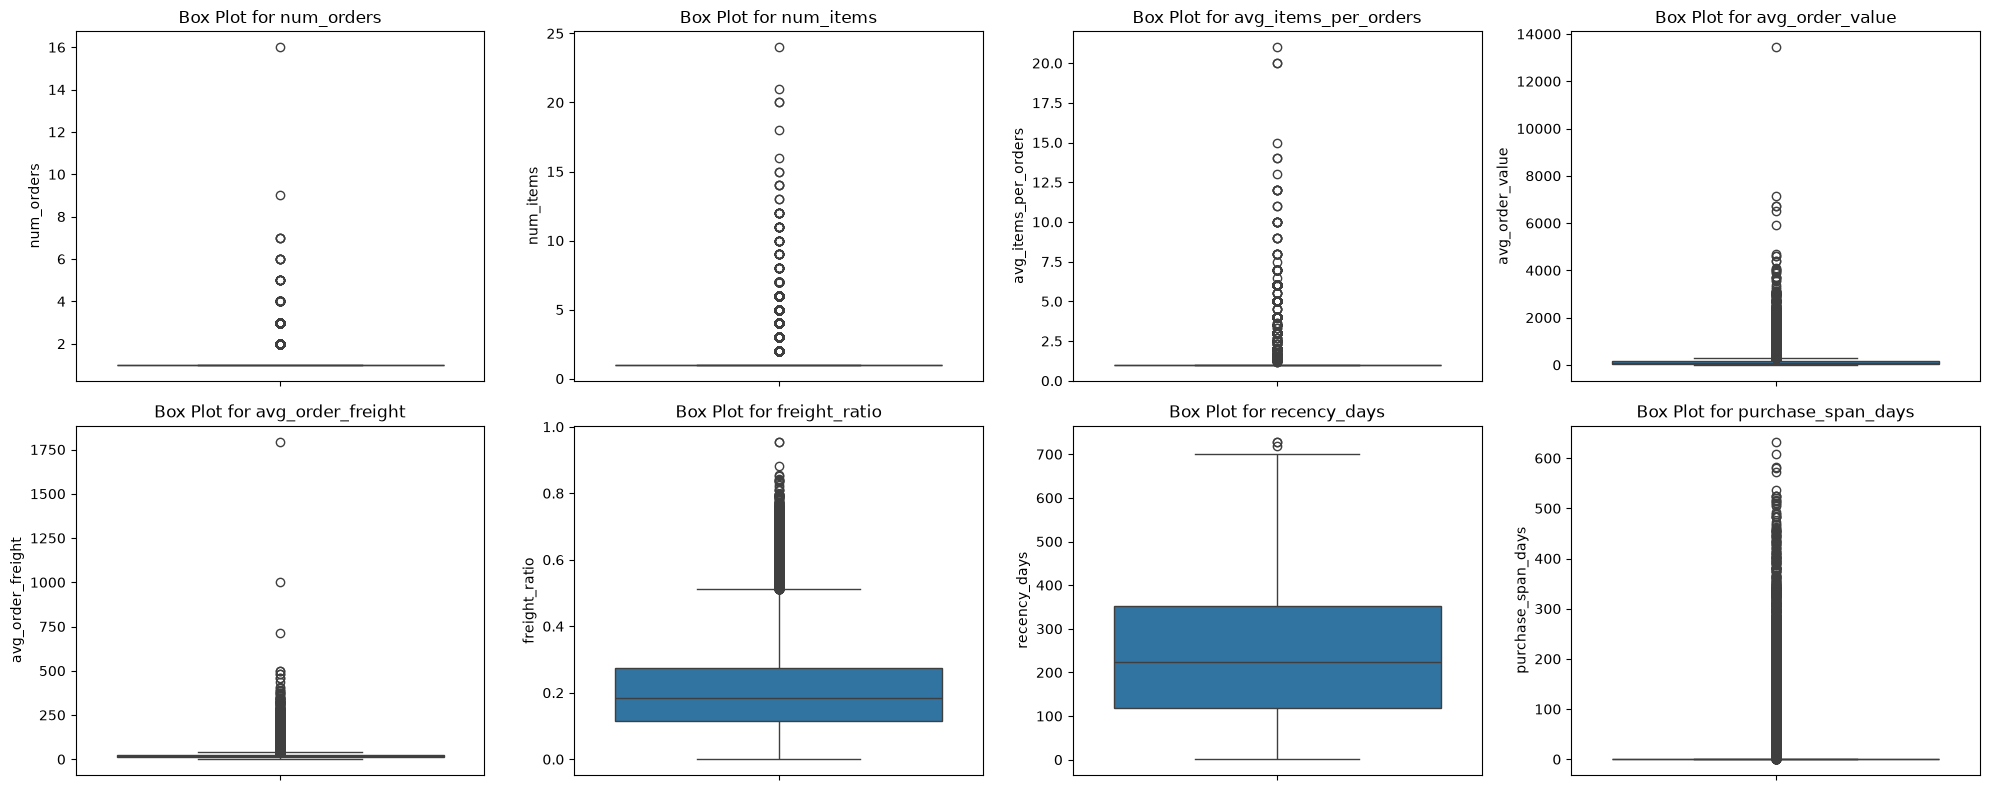

In [174]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_customers_behavior_cleaned_df.columns) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(numeric_customers_behavior_cleaned_df.columns):
    sns.boxplot(
        data=numeric_customers_behavior_cleaned_df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# إخفاء الـaxes الزائدة
for i in range(len(numeric_customers_behavior_cleaned_df.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

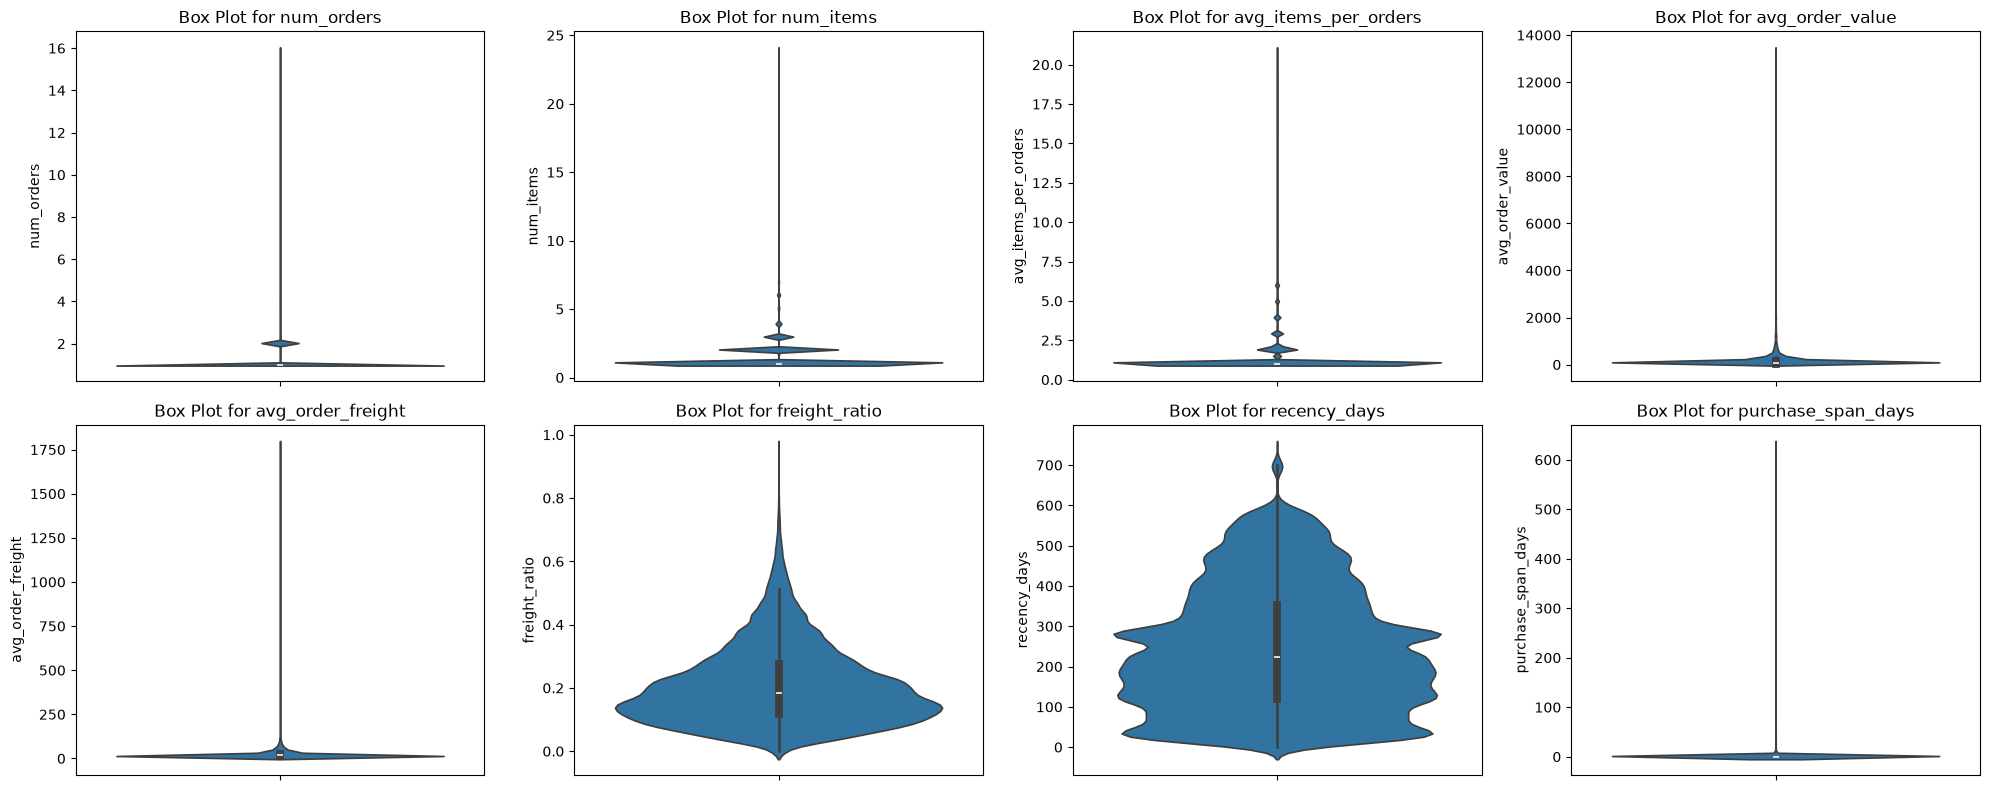

In [175]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_customers_behavior_cleaned_df.columns) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(numeric_customers_behavior_cleaned_df.columns):
    sns.violinplot(
        data=numeric_customers_behavior_cleaned_df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Box Plot for {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# إخفاء الـaxes الزائدة
for i in range(len(numeric_customers_behavior_cleaned_df.columns), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [176]:
features = [
    'num_orders',
    'num_items',
    'avg_items_per_orders',
    'avg_order_value',
    'avg_order_freight',
    'freight_ratio',
    'recency_days',
    'purchase_span_days'
]

customers_behavior_cleaned_df[features].skew().sort_values(ascending=False)

purchase_span_days     12.26
avg_order_freight      12.24
num_orders             11.44
avg_order_value         9.78
avg_items_per_orders    7.59
num_items               7.41
freight_ratio           1.07
recency_days            0.45
dtype: float64

In [177]:
customers_behavior_cleaned_df[features].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99]
)

,num_orders,num_items,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days
0.50,1.00,1.00,1.00,87.38,17.24,0.18,224.00,0.00
0.75,1.00,1.00,1.00,149.90,24.13,0.27,353.00,0.00
0.90,1.00,2.00,1.50,269.90,39.38,0.38,472.00,0.00
0.95,1.00,2.00,2.00,399.90,54.72,0.45,526.00,0.00
0.99,2.00,4.00,3.00,999.00,104.42,0.59,581.00,94.81


In [178]:
customers_behavior_cleaned_df = customers_behavior_cleaned_df.drop(['num_items','purchase_span_days','state'],axis=1)

In [179]:
customers_behavior_cleaned_df.isna().sum()

customer_unique_id      0
num_orders              0
avg_items_per_orders    0
avg_order_value         0
avg_order_freight       0
freight_ratio           0
recency_days            0
dtype: int64

In [180]:
customers_behavior_cleaned_df.duplicated().sum()

np.int64(0)

In [181]:
len(customers_behavior_cleaned_df)

95420

In [182]:
customers_behavior_cleaned_df.describe()

,num_orders,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days
count,"95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00"
mean,1.03,1.14,138.23,22.82,0.21,243.60
std,0.21,0.53,211.41,21.56,0.13,153.16
min,1.00,1.00,0.85,0.00,0.00,1.00
25%,1.00,1.00,46.40,13.89,0.12,119.00
50%,1.00,1.00,87.38,17.24,0.18,224.00
75%,1.00,1.00,149.90,24.13,0.27,353.00
max,16.00,21.00,"13,440.00","1,794.96",0.96,729.00


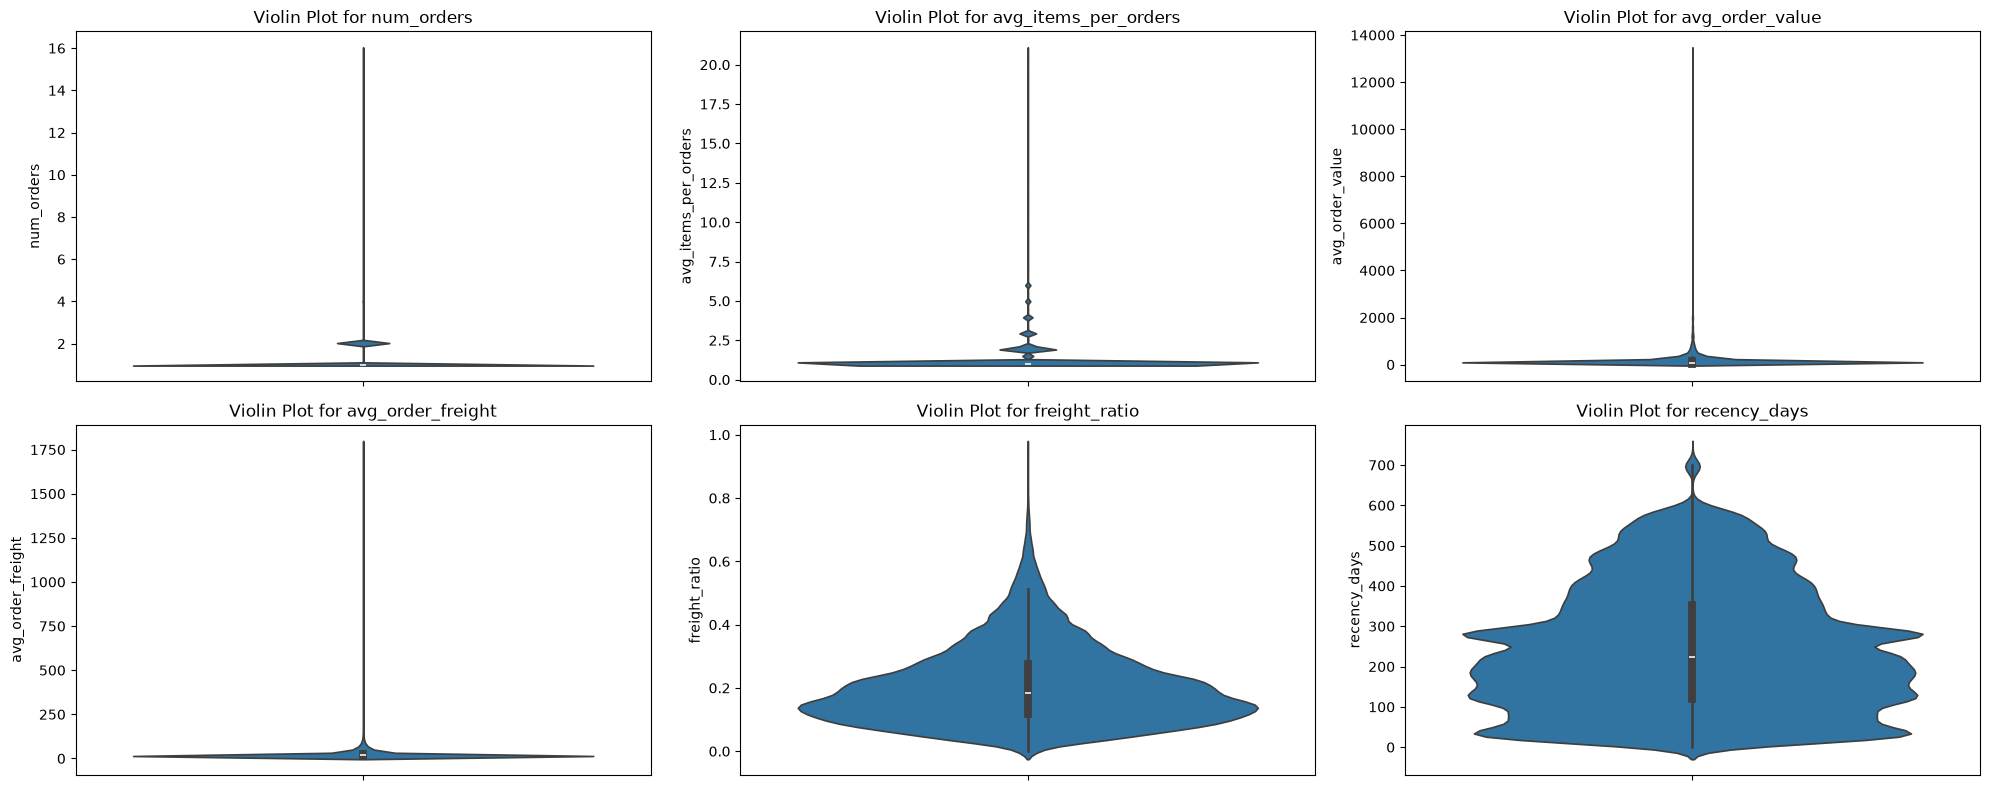

In [183]:
numerical_cols = customers_behavior_cleaned_df.select_dtypes(
    include='number'
).columns

n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 4 * n_rows)
)

axes = np.array(axes).flatten()

for i, col in enumerate(numerical_cols):
    sns.violinplot(
        data=customers_behavior_cleaned_df,
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'Violin Plot for {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

for i in range(len(numerical_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [184]:
customers_behavior_df.sort_values('num_items',ascending=False).head(10) 

,customer_unique_id,num_orders,num_items,total_price,total_freight,state,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days,purchase_span_days,repeate_customer
74752,c8460e4251689ba205045f3ea17884a1,4,24,"4,080.00",575.88,RS,6.00,"1,020.00",143.97,0.12,26,1,1
25885,4546caea018ad8c692964e3382debd19,1,21,31.80,164.37,SP,21.00,31.80,164.37,0.84,414,0,0
39443,698e1cf81d01a3d389d96145f7fa6df8,1,20,"1,974.00",288.80,GO,20.00,"1,974.00",288.80,0.13,376,0,0
73155,c402f431464c72e27330a67f7b94d4fb,1,20,"2,000.00",202.40,SP,20.00,"2,000.00",202.40,0.09,193,0,0
5741,0f5ac8d5c31de21d2f25e24be15bbffb,2,18,"1,252.35",292.47,PR,9.00,626.17,146.23,0.19,280,3,1
52597,8d50f5eadf50201ccdcedfb9e2ac8455,16,16,729.62,172.42,SP,1.00,45.60,10.78,0.19,14,461,1
87642,eae0a83d752b1dd32697e0e7b4221656,2,15,"1,821.73",961.28,BA,7.50,910.87,480.64,0.35,132,81,1
6760,11f97da02237a49c8e783dfda6f50e8e,1,15,765.00,18.00,GO,15.00,765.00,18.00,0.02,581,0,0
23302,3e43e6105506432c953e165fb2acf44c,9,14,"1,000.85",171.82,SP,1.56,111.21,19.09,0.15,188,161,1
18680,31e412b9fb766b6794724ed17a41dfa6,1,14,826.00,188.02,SP,14.00,826.00,188.02,0.19,264,0,0


In [185]:
orders_customers_items_df[orders_customers_items_df['customer_unique_id'] == '4546caea018ad8c692964e3382debd19'][[
    'order_id',
    'customer_id',
    'order_item_id',
    'price',
    'product_id',
    'order_purchase_timestamp'
]]

,order_id,customer_id,order_item_id,price,product_id,order_purchase_timestamp
100528,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,1,1.20,270516a3f41dc035aa87d220228f844c,2017-07-16 18:19:25
100529,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,2,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100530,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,3,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100531,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,4,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100532,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,5,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100533,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,6,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100534,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,7,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100535,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,8,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100536,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,9,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25
100537,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,10,1.20,05b515fdc76e888aada3c6d66c201dff,2017-07-16 18:19:25


In [186]:
orders_customers_items_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [187]:
customers_behavior_cleaned_df.head()

,customer_unique_id,num_orders,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days
0,0000366f3b9a7992bf8c76cfdf3221e2,1,1.00,129.90,12.00,0.08,116
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,1.00,18.90,8.29,0.30,119
2,0000f46a3911fa3c0805444483337064,1,1.00,69.00,17.22,0.20,542
3,0000f6ccb0745a6a4b88665a16c9f078,1,1.00,25.99,17.63,0.40,326
4,0004aac84e0df4da2b147fca70cf8255,1,1.00,180.00,16.89,0.09,293


In [188]:
orders_customers_items_cleaned_df.duplicated(
    subset=['order_id', 'order_item_id'],
    keep=False
).sum()

np.int64(0)

In [189]:
customers_behavior_cleaned_df.describe()

,num_orders,avg_items_per_orders,avg_order_value,avg_order_freight,freight_ratio,recency_days
count,"95,420.00","95,420.00","95,420.00","95,420.00","95,420.00","95,420.00"
mean,1.03,1.14,138.23,22.82,0.21,243.60
std,0.21,0.53,211.41,21.56,0.13,153.16
min,1.00,1.00,0.85,0.00,0.00,1.00
25%,1.00,1.00,46.40,13.89,0.12,119.00
50%,1.00,1.00,87.38,17.24,0.18,224.00
75%,1.00,1.00,149.90,24.13,0.27,353.00
max,16.00,21.00,"13,440.00","1,794.96",0.96,729.00


In [190]:
orders_customers_items_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [191]:
orders_customers_items_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
dtype: int64

In [192]:
len(orders_customers_items_df[orders_customers_items_df.duplicated(subset=["order_id"])])

13984

In [193]:
orders_customers_items_df[orders_customers_items_df.duplicated(subset=["order_id"])]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
11,e6ce16cb79ec1d90b1da9085a6118aeb,494dded5b201313c64ed7f100595b95c,delivered,2017-05-16 19:41:10,2017-05-16 19:50:18,2017-05-18 11:40:40,2017-05-29 11:18:31,2017-06-07 00:00:00,f2a85dec752b8517b5e58a06ff3cd937,20780,rio de janeiro,RJ,2,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-22 19:50:18,99.00,30.53
28,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,2018-06-05 00:35:10,2018-06-05 13:24:00,2018-06-16 15:20:55,2018-07-18 00:00:00,576ea0cab426cd8a00fad9a9c90a4494,41213,salvador,BA,2,9451e630d725c4bb7a5a206b48b99486,d673a59aac7a70d8b01e6902bf090a11,2018-06-13 00:35:10,39.50,48.64
55,9faeb9b2746b9d7526aef5acb08e2aa0,79183cd650e2bb0d475b0067d45946ac,delivered,2018-07-26 14:39:59,2018-07-26 14:55:10,2018-07-27 12:04:00,2018-07-31 22:26:55,2018-08-16 00:00:00,c77154776ead8e798c2d684205938f71,90620,porto alegre,RS,2,f48eb5c2fde13ca63664f0bb05f55346,f7ba60f8c3f99e7ee4042fdef03b70c4,2018-07-30 14:55:10,60.00,15.52
61,66e4624ae69e7dc89bd50222b59f581f,684fa6da5134b9e4dab731e00011712d,delivered,2018-03-09 14:50:15,2018-03-09 15:40:39,2018-03-15 00:31:19,2018-04-03 13:28:46,2018-04-02 00:00:00,ddf60e20e6e262e2136801ce5cd628b0,49030,aracaju,SE,2,b37b72d5a56f887725c2862184b8cab8,db4350fd57ae30082dec7acbaacc17f9,2018-03-15 15:30:45,22.99,22.85
69,688052146432ef8253587b930b01a06d,81e08b08e5ed4472008030d70327c71f,delivered,2018-04-22 08:48:13,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58,2018-05-15 00:00:00,0e764fc1a13e47e900c3d59a989753e8,36045,juiz de fora,MG,2,db56f6d2b04c89eae4daba188842fd7b,2a84855fd20af891be03bc5924d2b453,2018-04-26 09:31:11,199.00,3.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112595,83db27f85506380229913b0dfdf5cd18,472acc24324ad4cee482fe4ef5910dc1,delivered,2018-04-18 12:35:58,2018-04-19 02:51:26,2018-05-02 08:52:00,2018-05-07 16:40:55,2018-05-29 00:00:00,35a382f91046bec8ef1acb7dc62b7318,21931,rio de janeiro,RJ,2,86f2416d4670e4ea3ca5494d043d9f24,7c67e1448b00f6e969d365cea6b010ab,2018-05-04 02:51:26,149.94,49.15
112603,b3112ca67f3afd4e20cf2ee91fc4f804,6f83c71b6c044fb156d697d4130fe9b5,delivered,2018-08-02 22:46:54,2018-08-02 23:04:06,2018-08-15 17:42:00,2018-08-21 00:03:26,2018-08-16 00:00:00,f690f0caffab80b6f849f08ba1692925,9330,maua,SP,2,4f18ca9862f511ecba98258b2194d061,5b0cc932433fa5184b5b94bfe6bcc256,2018-08-08 23:04:06,95.00,24.75
112622,e8fd20068b9f7e6ec07068bb7537f781,609b9fb8cad4fe0c7b376f77c8ab76ad,delivered,2017-08-10 21:21:07,2017-08-10 21:35:26,2017-08-18 16:42:51,2017-08-23 15:36:29,2017-08-31 00:00:00,fb9310710003399b031add3e55f34719,3318,sao paulo,SP,2,0df37da38a30a713453b03053d60d3f7,218d46b86c1881d022bce9c68a7d4b15,2017-08-17 21:35:26,356.00,18.12
112641,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07 00:00:00,c716cf2b5b86fb24257cffe9e7969df8,78048,cuiaba,MT,2,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,2017-10-10 20:07:14,26.90,36.98


In [194]:
orders_customers_items_df[orders_customers_items_df.duplicated(subset=["order_id"])]['order_id'].value_counts()

order_id
8272b63d03f5f79c56e9e4120aec44ef    20
1b15974a0141d54e36626dca3fdc731a    19
ab14fdcfbe524636d65ee38360e22ce8    19
428a2f660dc84138d969ccd69a0ab6d5    14
9ef13efd6949e4573a18964dd1bbe7f5    14
                                    ..
83db27f85506380229913b0dfdf5cd18     1
b3112ca67f3afd4e20cf2ee91fc4f804     1
e8fd20068b9f7e6ec07068bb7537f781     1
9115830be804184b91f5c00f6f49f92d     1
11c177c8e97725db2631073c19f07b62     1
Name: count, Length: 9803, dtype: int64

In [195]:
orders_customers_items_df[orders_customers_items_df.order_id == "8272b63d03f5f79c56e9e4120aec44ef"]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
100528,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100529,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100530,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100531,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100532,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100533,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100534,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100535,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100536,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,9,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
100537,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,2017-07-16 18:19:25,2017-07-17 18:25:23,2017-07-20 15:45:53,2017-07-31 18:03:02,2017-07-28 00:00:00,4546caea018ad8c692964e3382debd19,5882,sao paulo,SP,10,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89


dublicated orders not error, data in item level

In [196]:
orders_customers_items_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [197]:
order_lv_df = (
    orders_customers_items_cleaned_df
    .groupby([
        'order_id',
        'customer_id',
        'order_status',
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'customer_unique_id',
        'customer_zip_code_prefix',
        'customer_city',
        'customer_state'
    ],dropna=False)
    .agg(
        total_price=('price', 'sum'),
        total_frieght=('freight_value', 'sum'),
        item_count=('order_item_id', 'count')
    )
    .reset_index()
)

In [198]:
order_lv_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,199.90,18.14,1


In [199]:
order_lv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98666 entries, 0 to 98665
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98666 non-null  str           
 1   customer_id                    98666 non-null  str           
 2   order_status                   98666 non-null  str           
 3   order_purchase_timestamp       98666 non-null  datetime64[us]
 4   order_approved_at              98652 non-null  datetime64[us]
 5   order_delivered_carrier_date   97657 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  98666 non-null  datetime64[us]
 8   customer_unique_id             98666 non-null  str           
 9   customer_zip_code_prefix       98666 non-null  int64         
 10  customer_city                  98666 non-null  str           
 11  customer_state            

In [200]:
order_lv_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1009
order_delivered_customer_date    2190
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_price                         0
total_frieght                       0
item_count                          0
dtype: int64

In [201]:
print(len(orders_customers_items_df))
print(len(order_lv_df))

print(orders_customers_items_df['order_id'].nunique())
print(order_lv_df['order_id'].nunique())

112650
98666
98666
98666


records with late delivered

In [202]:
order_lv_df[
    order_lv_df.order_approved_at.isna()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
7222,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20,c8822fce1d0bfa7ddf0da24fff947172,27945,macae,RJ,79.99,15.77,1
16680,2babbb4b15e6d2dfe95e2de765c97bce,74bebaf46603f9340e3b50c6b086f992,delivered,2017-02-18 17:15:03,NaT,2017-02-22 11:23:11,2017-03-03 18:43:43,2017-03-31,f79be7c08dd24b72d34634f1b89333a4,65110,sao jose de ribamar,MA,79.99,26.82,1
17963,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaT,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20,5a4fa4919cbf2b049e72be460a380e5b,35620,abaete,MG,135.00,19.23,1
23110,3c0b8706b065f9919d0505d3b3343881,d85919cb3c0529589c6fa617f5f43281,delivered,2017-02-17 15:53:27,NaT,2017-02-22 11:31:30,2017-03-03 11:47:47,2017-03-23,c094ac95fcd52f821809ec232a7a6956,95795,sao vendelino,RS,133.99,23.20,1
31595,51eb2eebd5d76a24625b31c33dd41449,07a2a7e0f63fd8cb757ed77d4245623c,delivered,2017-02-18 15:52:27,NaT,2017-02-23 03:09:14,2017-03-07 13:57:47,2017-03-29,79af1bbf230a2630487975aa5d7d6220,37660,paraisopolis,MG,59.90,17.16,1
35717,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31,7e1a5ca61b572d76b64b6688b9f96473,62700,caninde,CE,79.99,26.82,1
43169,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaT,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16,d49f3dae6bad25d05160fc17aca5942d,36400,conselheiro lafaiete,MG,45.90,14.52,1
43192,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaT,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17,e1f01a1bd6485e58ad3c769a5427d8a8,8230,sao paulo,SP,49.99,15.53,1
52234,88083e8f64d95b932164187484d90212,f67cd1a215aae2a1074638bbd35a223a,delivered,2017-02-18 22:49:19,NaT,2017-02-22 11:31:06,2017-03-02 12:06:06,2017-03-21,bc1896dc77f49e6dec880445a9b443a3,21020,rio de janeiro,RJ,98.00,29.04,2
53225,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21,91efb7fcabc17925099dced52435837f,93548,novo hamburgo,RS,379.00,17.86,1


#### observation : There are unapproved requests, yet their status is "Delivered".
#### desicion : drop **order_approved_at** column

In [203]:
order_lv_df[
    order_lv_df.order_delivered_carrier_date.isna()
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
76,00310b0c75bb13015ec4d82d341865a4,0dad07848c618cc5a4679a1bfe1db8d2,canceled,2018-08-15 14:29:08,2018-08-15 15:04:25,NaT,NaT,2018-08-29,ec979208947bbba310f2ad8e50963725,31160,belo horizonte,MG,39.90,15.38,1
244,00ae7a8b4936674ebb701d4a23719a79,a7e8a3cb55d9c9a536992c6465a46a3f,canceled,2018-05-09 14:14:06,2018-05-09 15:51:32,NaT,NaT,2018-05-17,f0b9f688a3b9151bc6b38f4b5b36ea44,6539,santana de parnaiba,SP,27.90,9.26,1
374,00ff0cf5583758e6964723e42f111bf4,e3626ed5d1f2e3a02d692ec948b25eeb,canceled,2017-04-10 00:45:56,2017-04-10 01:03:29,NaT,NaT,2017-05-04,b9badb100ff8ecc16a403111209e3a06,88025,florianopolis,SC,154.90,15.25,1
479,013e9c654a339d80b53513da3c1ea437,9391729f79cd9e5fd7ca884ca030f579,canceled,2017-06-18 13:48:48,2017-06-18 13:55:18,NaT,NaT,2017-07-07,05a3b50193563913613acada5c86b1d2,18710,arandu,SP,109.90,13.11,1
489,0148d3df00cebda592d4e5f966e300cc,672510553bcfbf72de694db2cd88f046,canceled,2017-08-19 19:08:26,2017-08-19 19:24:32,NaT,NaT,2017-09-11,e75fd09539dff5c7c80a12781404ffea,4078,sao paulo,SP,27.65,59.25,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98083,fe67d9fbc13fc8b281cfab9b09f60607,2fcf059f0e80fc034f5bc5e878e9115b,invoiced,2017-12-15 17:46:39,2017-12-15 18:31:43,NaT,NaT,2018-01-16,8085f1482c093a7af04e397f07a88498,9361,maua,SP,201.00,13.57,1
98155,fe9aa3b22b4d65ccbaffb57984bc12fb,e14603210bf5355859bea3b45bbad044,canceled,2017-11-14 19:30:10,2017-11-14 19:50:28,NaT,NaT,2017-11-28,0f1443bd810ee6fcfa261d95ff34446f,13305,itu,SP,39.90,7.78,1
98216,fec76d3c7d37a989bdd3a22911340c75,ca8fb6422920b579e8d074784240c05f,processing,2018-01-19 14:24:31,2018-01-20 15:22:02,NaT,NaT,2018-02-09,1eb492e4bf295a22e567c08f24399a67,6465,barueri,SP,429.90,41.94,1
98221,fecc4ea5a3e06ce3192ae2f05b7a8439,ec43686dd7b2f48ea65475606fdfc85d,processing,2018-01-14 21:52:31,2018-01-14 22:09:08,NaT,NaT,2018-02-06,12bf6178776d90da204cdf1b37d23906,13214,jundiai,SP,159.60,56.40,4


In [204]:
order_lv_df[
    order_lv_df.order_delivered_carrier_date.isna()
]['order_status'].value_counts()

order_status
canceled       386
invoiced       312
processing     301
unavailable      6
approved         2
delivered        2
Name: count, dtype: int64

In [205]:
order_lv_df[
    (order_lv_df.order_delivered_carrier_date.isna())\
        & (order_lv_df.order_status == "delivered")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
16294,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14,a2ac81ecc3704410ae240e74d4f0af40,13334,indaiatuba,SP,179.00,14.98,1
17404,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23,d77cf4be2654aa70ef150f8bfec076a6,91330,porto alegre,RS,179.00,15.00,1


show orders with nan order_delivered_carrier_date and no nan order_delivered_customer_date

In [206]:
order_lv_df[
    (order_lv_df.order_delivered_carrier_date.isna())\
        & (order_lv_df.order_delivered_customer_date.notna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
16294,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14,a2ac81ecc3704410ae240e74d4f0af40,13334,indaiatuba,SP,179.00,14.98,1


In [207]:
order_lv_df[
     (order_lv_df.order_delivered_customer_date.isna())
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
72,002f19a65a2ddd70a090297872e6d64e,7fa80efb1ef15ca4104627910c29791c,shipped,2018-03-21 13:05:30,2018-03-21 13:15:27,2018-03-22 00:13:35,NaT,2018-04-16,205d5aa158338f2b733a07326aae8c87,42804,camacari,BA,53.98,23.31,1
76,00310b0c75bb13015ec4d82d341865a4,0dad07848c618cc5a4679a1bfe1db8d2,canceled,2018-08-15 14:29:08,2018-08-15 15:04:25,NaT,NaT,2018-08-29,ec979208947bbba310f2ad8e50963725,31160,belo horizonte,MG,39.90,15.38,1
234,00a99c50fdff7e36262caba33821875a,7a399396442d5601cbedfbd0a3cf1da4,shipped,2018-08-17 16:25:04,2018-08-17 16:35:18,2018-08-18 09:07:00,NaT,2018-09-18,60ec651482858c327c177cf9360cc0a2,45990,teixeira de freitas,BA,52.99,22.30,1
244,00ae7a8b4936674ebb701d4a23719a79,a7e8a3cb55d9c9a536992c6465a46a3f,canceled,2018-05-09 14:14:06,2018-05-09 15:51:32,NaT,NaT,2018-05-17,f0b9f688a3b9151bc6b38f4b5b36ea44,6539,santana de parnaiba,SP,27.90,9.26,1
374,00ff0cf5583758e6964723e42f111bf4,e3626ed5d1f2e3a02d692ec948b25eeb,canceled,2017-04-10 00:45:56,2017-04-10 01:03:29,NaT,NaT,2017-05-04,b9badb100ff8ecc16a403111209e3a06,88025,florianopolis,SC,154.90,15.25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98278,feebdfdb4759bd4600d52547c81b4fa8,5c296f7939550b876425980a5d7da5ce,shipped,2017-09-25 08:57:20,2017-09-25 09:10:09,2017-09-27 15:18:41,NaT,2017-10-24,51e96af5f0314b37ecdc524b4c44c06a,58011,joao pessoa,PB,24.90,21.15,1
98315,ff0768e3356919b32e3d7f30baecfcfb,f3e5d57c12abb230c4f16b6a0a23d7f7,shipped,2018-04-04 22:58:39,2018-04-04 23:10:13,2018-04-05 22:59:25,NaT,2018-04-23,7425df6fd8a9ae635b5eab764d75b8e8,19050,presidente prudente,SP,379.90,20.54,1
98388,ff358345576214cc9e08488188973c84,8da33bbf65a0b181486063ffb90fa3d6,shipped,2018-03-03 17:05:12,2018-03-03 17:29:04,2018-03-05 17:18:58,NaT,2018-04-02,7dd99cf6066756d22317b540493c24fd,24913,marica,RJ,19.90,16.79,1
98429,ff536d93ae4214b4d51c2894ccfc569f,8891eb5ca0e28df961b2b5b8f3c0eb23,shipped,2017-12-21 09:01:00,2017-12-22 12:33:26,2018-01-03 18:22:09,NaT,2018-01-10,13ac6da47fef1b17b16f511e03b57918,2632,sao paulo,SP,39.00,8.27,1


In [208]:
order_lv_df[
     (order_lv_df.order_delivered_customer_date.isna())
]['order_status'].value_counts()

order_status
shipped        1106
canceled        455
invoiced        312
processing      301
delivered         8
unavailable       6
approved          2
Name: count, dtype: int64

In [209]:
order_lv_df[
     (order_lv_df.order_delivered_customer_date.isna())\
          & (order_lv_df.order_status == "delivered")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
5125,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24,ebf7e0d43a78c81991a4c59c145c75db,13560,sao carlos,SP,188.99,15.63,1
12673,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19,175378436e2978be55b8f4316bce4811,9431,ribeirao pires,SP,45.90,9.07,1
17229,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,13467e882eb3a701826435ee4424f2bd,18520,cerquilho,SP,117.30,17.53,1
17404,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23,d77cf4be2654aa70ef150f8bfec076a6,91330,porto alegre,RS,179.00,15.00,1
17890,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30,1bd06a0c0df8b23dacfd3725d2dc0bb9,12445,pindamonhangaba,SP,139.00,19.07,1
65872,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26,cce5e8188bf42ffb3bb5b18ff58f5965,7261,guarulhos,SP,110.99,9.13,1
88997,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30,3bc508d482a402715be4d5cf4020cc81,13170,sumare,SP,139.00,19.07,1
94741,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,2f17c5b324ad603491521b279a9ff4de,18255,quadra,SP,329.00,25.24,1


#### observation : there are orders with missing values delivered customer date however orders status is deliverd
#### desicion : remove these rows

In [210]:
order_lv_df[
     (order_lv_df.order_delivered_customer_date.isna())\
          & (order_lv_df.order_status == "delivered")
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
5125,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24,ebf7e0d43a78c81991a4c59c145c75db,13560,sao carlos,SP,188.99,15.63,1
12673,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19,175378436e2978be55b8f4316bce4811,9431,ribeirao pires,SP,45.90,9.07,1
17229,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,13467e882eb3a701826435ee4424f2bd,18520,cerquilho,SP,117.30,17.53,1
17404,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23,d77cf4be2654aa70ef150f8bfec076a6,91330,porto alegre,RS,179.00,15.00,1
17890,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30,1bd06a0c0df8b23dacfd3725d2dc0bb9,12445,pindamonhangaba,SP,139.00,19.07,1
65872,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26,cce5e8188bf42ffb3bb5b18ff58f5965,7261,guarulhos,SP,110.99,9.13,1
88997,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30,3bc508d482a402715be4d5cf4020cc81,13170,sumare,SP,139.00,19.07,1
94741,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,2f17c5b324ad603491521b279a9ff4de,18255,quadra,SP,329.00,25.24,1


In [211]:
late_orders = order_lv_df[
    order_lv_df['order_delivered_customer_date'] >
    order_lv_df['order_estimated_delivery_date']
]

In [212]:
print(f"late orders percentage : {(len(late_orders) /len(orders_customers_cleaned_df) * 100)}%")

late orders percentage : 7.870998883760219%


In [213]:
late_orders.info()

<class 'pandas.DataFrame'>
Index: 7827 entries, 8 to 98657
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       7827 non-null   str           
 1   customer_id                    7827 non-null   str           
 2   order_status                   7827 non-null   str           
 3   order_purchase_timestamp       7827 non-null   datetime64[us]
 4   order_approved_at              7827 non-null   datetime64[us]
 5   order_delivered_carrier_date   7826 non-null   datetime64[us]
 6   order_delivered_customer_date  7827 non-null   datetime64[us]
 7   order_estimated_delivery_date  7827 non-null   datetime64[us]
 8   customer_unique_id             7827 non-null   str           
 9   customer_zip_code_prefix       7827 non-null   int64         
 10  customer_city                  7827 non-null   str           
 11  customer_state                 7

In [214]:
late_orders.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,total_price,total_frieght,item_count
count,7827,7827,7826,7827,7827,"7,827.00","7,827.00","7,827.00","7,827.00"
mean,2018-01-25 13:44:15.539798,2018-01-26 02:03:00.938673,2018-01-31 10:05:44.150779,2018-02-26 02:11:11.900728,2018-02-16 12:56:01.287849,"37,627.91",148.07,24.62,1.11
min,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,"1,009.00",3.54,0.00,1.00
25%,2017-11-24 23:08:32.500000,2017-11-25 10:15:51,2017-11-29 23:47:07.500000,2017-12-26 22:23:03.500000,2017-12-19 00:00:00,"13,321.00",49.00,15.10,1.00
50%,2018-02-21 20:21:57,2018-02-22 02:30:46,2018-02-26 21:48:22,2018-03-23 23:18:29,2018-03-16 00:00:00,"28,625.00",89.90,18.05,1.00
75%,2018-03-31 11:55:32,2018-03-31 19:30:17,2018-04-04 21:00:54,2018-05-07 13:03:25,2018-04-24 00:00:00,"60,349.50",159.90,26.43,1.00
max,2018-08-28 22:51:54,2018-08-28 23:05:10,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-08-31 00:00:00,"99,900.00","6,729.00",711.33,21.00
std,NaN,NaN,NaN,NaN,NaN,"28,204.10",226.17,22.83,0.50


In [215]:
late_orders.describe(include='O')

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state
count,7827,7827,7827,7827,7827,7827
unique,7827,7827,2,7772,1299,27
top,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,delivered,d26c616e241736e0c1c1ab14150239e7,sao paulo,SP
freq,1,1,7826,3,942,2387


In [216]:
late_orders['order_status'].value_counts()

order_status
delivered    7826
canceled        1
Name: count, dtype: int64

In [217]:
late_orders[late_orders.order_status == 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
9766,1950d777989f6a877539f53795b4c3c3,1bccb206de9f0f25adc6871a1bcf77b2,canceled,2018-02-19 19:48:52,2018-02-19 20:56:05,2018-02-20 19:57:13,2018-03-21 22:03:51,2018-03-09,6a04c8339c44b23e189446216a494569,32071,contagem,MG,29.99,14.10,1


In [218]:
late_orders['customer_city'].value_counts().head(20)

customer_city
sao paulo                942
rio de janeiro           780
salvador                 208
belo horizonte           166
porto alegre             158
brasilia                 147
campinas                 143
fortaleza                111
niteroi                  103
sao goncalo               96
recife                    79
goiania                   76
sao luis                  75
curitiba                  74
guarulhos                 72
florianopolis             71
maceio                    70
santos                    65
teresina                  60
sao bernardo do campo     57
Name: count, dtype: int64

In [219]:
customers_by_city_df = order_lv_df.groupby("customer_city")\
    .agg(
        total_orders = ('customer_city','count')
    ).reset_index()
    

In [220]:
customers_by_city_df.sort_values(by='total_orders',ascending=False).head()

,customer_city,total_orders
3588,sao paulo,15402
3147,rio de janeiro,6834
452,belo horizonte,2750
557,brasilia,2116
1141,curitiba,1510


In [221]:
dict_orders_city_num = {}

customers_by_city_df.sort_values(by='total_orders',ascending=False,inplace=True)

for i in range(customers_by_city_df.shape[0]):
    dict_orders_city_num[customers_by_city_df.iloc[i,0]] = int(customers_by_city_df.iloc[i,1])

list(dict_orders_city_num.items())[:5]


[('sao paulo', 15402),
 ('rio de janeiro', 6834),
 ('belo horizonte', 2750),
 ('brasilia', 2116),
 ('curitiba', 1510)]

In [222]:
late_orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count
8,0005a1a1728c9d785b8e2b08b904576c,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,2018-03-20 18:35:21,2018-03-28 00:37:42,2018-03-29 18:17:31,2018-03-29,639d23421f5517f69d0c3d6e6564cf0e,11075,santos,SP,145.95,11.65,1
11,00063b381e2406b52ad429470734ebd5,6a899e55865de6549a58d2c6845e5604,delivered,2018-07-27 17:21:27,2018-07-27 18:00:06,2018-07-30 14:52:00,2018-08-07 13:56:52,2018-08-07,3fb97204945ca0c01bcf3eee6031c5f1,15910,monte alto,SP,45.00,12.98,1


In [223]:
late_orders_by_city_df = late_orders.groupby('customer_city')\
    .agg(
        total_orders = ('customer_city','count')
    ).reset_index()

In [224]:
late_orders_by_city_df.sort_values(by='total_orders',ascending=False,inplace=True)

In [225]:
late_orders_by_city_df.head()

,customer_city,total_orders
1126,sao paulo,942
980,rio de janeiro,780
1007,salvador,208
129,belo horizonte,166
920,porto alegre,158


In [226]:
late_orders_per_city_percentage = {}
for i in range(late_orders_by_city_df.shape[0]):
    try:

        current_city = str(late_orders_by_city_df.iloc[i,0])
        num_orders_of_current_city = dict_orders_city_num[current_city]
        num_lated_orders_of_current_city = int(late_orders_by_city_df.iloc[i,1])
        percentage = round((num_lated_orders_of_current_city / num_orders_of_current_city) * 100,1)

        late_orders_per_city_percentage[current_city] = [num_orders_of_current_city,num_lated_orders_of_current_city,percentage]
    except Exception as e:
        raise Exception(f'erro : {e}')


In [227]:
list(late_orders_per_city_percentage.items())

[('sao paulo', [15402, 942, 6.1]),
 ('rio de janeiro', [6834, 780, 11.4]),
 ('salvador', [1238, 208, 16.8]),
 ('belo horizonte', [2750, 166, 6.0]),
 ('porto alegre', [1372, 158, 11.5]),
 ('brasilia', [2116, 147, 6.9]),
 ('campinas', [1429, 143, 10.0]),
 ('fortaleza', [650, 111, 17.1]),
 ('niteroi', [845, 103, 12.2]),
 ('sao goncalo', [406, 96, 23.6]),
 ('recife', [612, 79, 12.9]),
 ('goiania', [687, 76, 11.1]),
 ('sao luis', [348, 75, 21.6]),
 ('curitiba', [1510, 74, 4.9]),
 ('guarulhos', [1178, 72, 6.1]),
 ('florianopolis', [565, 71, 12.6]),
 ('maceio', [246, 70, 28.5]),
 ('santos', [706, 65, 9.2]),
 ('teresina', [280, 60, 21.4]),
 ('nova iguacu', [439, 57, 13.0]),
 ('sao bernardo do campo', [928, 57, 6.1]),
 ('vila velha', [333, 50, 15.0]),
 ('serra', [285, 43, 15.1]),
 ('vitoria', [378, 43, 11.4]),
 ('macae', [237, 42, 17.7]),
 ('belem', [445, 42, 9.4]),
 ('volta redonda', [228, 41, 18.0]),
 ('sao jose dos campos', [686, 40, 5.8]),
 ('campo grande', [315, 38, 12.1]),
 ('osasco', [74

In [228]:
late_orders_info = pd.DataFrame.from_dict(
    late_orders_per_city_percentage,
    orient='index',
    columns=['total_orders', 'late_orders', 'late_percentage']
)

late_orders_info.index.name = 'customer_city'

late_orders_info.reset_index(inplace=True)

late_orders_info.sort_values(by='late_percentage',ascending=False,inplace=True)

In [229]:
late_orders_info

,customer_city,total_orders,late_orders,late_percentage
1276,vila pereira,1,1,100.00
1275,vila nova do sul,1,1,100.00
1289,jacuizinho,1,1,100.00
1288,jacuipe,1,1,100.00
1285,jacareacanga,1,1,100.00
...,...,...,...,...
766,mogi mirim,76,1,1.30
1199,assis,84,1,1.20
577,vinhedo,94,1,1.10
603,itatiba,97,1,1.00


In [230]:
late_orders_info = late_orders_info[
    late_orders_info['total_orders'] >= 50
]

In [231]:
late_orders_info.sort_values(
    by='late_percentage',
    ascending=False,
    inplace=True
)

In [232]:
late_orders_info

,customer_city,total_orders,late_orders,late_percentage
16,maceio,246,70,28.50
9,sao goncalo,406,96,23.60
42,cabo frio,116,27,23.30
12,sao luis,348,75,21.60
18,teresina,280,60,21.40
...,...,...,...,...
766,mogi mirim,76,1,1.30
1199,assis,84,1,1.20
577,vinhedo,94,1,1.10
603,itatiba,97,1,1.00


#### customer_city shows substantial variation in delivery delay rates, suggesting geographic location may be a useful predictive feature

In [233]:
order_lv_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98666 entries, 0 to 98665
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       98666 non-null  str           
 1   customer_id                    98666 non-null  str           
 2   order_status                   98666 non-null  str           
 3   order_purchase_timestamp       98666 non-null  datetime64[us]
 4   order_approved_at              98652 non-null  datetime64[us]
 5   order_delivered_carrier_date   97657 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  98666 non-null  datetime64[us]
 8   customer_unique_id             98666 non-null  str           
 9   customer_zip_code_prefix       98666 non-null  int64         
 10  customer_city                  98666 non-null  str           
 11  customer_state            

In [234]:
price_freight_items_df = order_lv_df[['total_price','total_frieght','item_count']]

price_freight_items_df.head()

,total_price,total_frieght,item_count
0,58.90,13.29,1
1,239.90,19.93,1
2,199.00,17.87,1
3,12.99,12.79,1
4,199.90,18.14,1


In [235]:
late_orders['item_count'].value_counts()

item_count
1     7198
2      490
3       81
4       28
6       16
5       13
21       1
Name: count, dtype: int64

In [236]:
late_orders_items_count = late_orders.groupby('item_count')\
    .agg(
        orders_count = ('item_count','count')
    )

order_lv_items_count = order_lv_df.groupby('item_count')\
    .agg(
        orders_count = ('item_count','count')
    )



In [237]:
late_orders_items_count

,orders_count
item_count,
1,7198
2,490
3,81
4,28
5,13
6,16
21,1


In [238]:
order_lv_items_count.columns


Index(['orders_count'], dtype='str')

In [239]:
dict_late_orders_by_item_percentage = {}
for i in late_orders_items_count.index:
    percentage = round(float(late_orders_items_count.loc[i,'orders_count'] / order_lv_items_count.loc[i,'orders_count']) * 100,1)
    dict_late_orders_by_item_percentage[i] = [int(late_orders_items_count.loc[i,'orders_count']),percentage]

del(percentage)
  

In [240]:
list(dict_late_orders_by_item_percentage.items())

[(1, [7198, 8.1]),
 (2, [490, 6.5]),
 (3, [81, 6.1]),
 (4, [28, 5.5]),
 (5, [13, 6.4]),
 (6, [16, 8.1]),
 (21, [1, 100.0])]

In [241]:
late_orders_by_item_percentage_df = pd.DataFrame.from_dict(
    dict_late_orders_by_item_percentage,
    orient='index',
    columns=[
        'total_lated_orders',
        'percentage_of_lated_orders_per_item_count'
    ]
)

late_orders_by_item_percentage_df.index.name = 'item_count'

late_orders_by_item_percentage_df.reset_index(inplace=True)

late_orders_by_item_percentage_df.sort_values(
    by='percentage_of_lated_orders_per_item_count',
    ascending=False,
    inplace=True
)

In [242]:
late_orders_by_item_percentage_df.sort_values(by='item_count')

,item_count,total_lated_orders,percentage_of_lated_orders_per_item_count
0,1,7198,8.10
1,2,490,6.50
2,3,81,6.10
3,4,28,5.50
4,5,13,6.40
5,6,16,8.10
6,21,1,100.00


In [243]:
order_lv_df['total_price'].min(),order_lv_df['total_price'].max() 

(np.float64(0.85), np.float64(13440.0))

In [244]:
late_orders['total_price'].min(),late_orders['total_price'].max() 

(np.float64(3.54), np.float64(6729.0))

In [245]:
price_bins = [0, 50, 100, 200, 500, 1000, float('inf')]
price_labels = ['0-50', '50-100', '100-200', '200-500', '500-1000', '1000+']

price_total_df = (
    pd.cut(
        order_lv_df['total_price'],
        bins=price_bins,
        labels=price_labels,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .reset_index()
)

price_total_df.columns = ['label', 'total']


price_late_df = (
    pd.cut(
        late_orders['total_price'],
        bins=price_bins,
        labels=price_labels,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .reset_index()
)

price_late_df.columns = ['label', 'total_late']


price_analysis_df = price_total_df.merge(
    price_late_df,
    on='label',
    how='left'
)

price_analysis_df['percentage'] = (
    price_analysis_df['total_late']
    / price_analysis_df['total']
    * 100
)

In [246]:
price_analysis_df.head()

,label,total,total_late,percentage
0,0-50,29654,2175,7.33
1,50-100,28189,2194,7.78
2,100-200,25831,2130,8.25
3,200-500,11375,1005,8.84
4,500-1000,2674,234,8.75


In [247]:
freight_bins = [0, 20, 50, 100, 200, 500, float('inf')]
freight_labels = ['0-20', '20-50', '50-100', '100-200', '200-500', '500+']

freight_total_df = (
    pd.cut(
        order_lv_df['total_frieght'],
        bins=freight_bins,
        labels=freight_labels,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .reset_index()
)

freight_total_df.columns = ['label', 'total']


freight_late_df = (
    pd.cut(
        late_orders['total_frieght'],
        bins=freight_bins,
        labels=freight_labels,
        include_lowest=True
    )
    .value_counts()
    .sort_index()
    .reset_index()
)

freight_late_df.columns = ['label', 'total_late']


freight_analysis_df = freight_total_df.merge(
    freight_late_df,
    on='label',
    how='left'
)

freight_analysis_df['percentage'] = (
    freight_analysis_df['total_late']
    / freight_analysis_df['total']
    * 100
)

In [248]:
freight_analysis_df.head()

,label,total,total_late,percentage
0,0-20,64866,4765,7.35
1,20-50,27546,2461,8.93
2,50-100,5151,483,9.38
3,100-200,945,107,11.32
4,200-500,153,10,6.54


In [249]:
order_lv_df.isna().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1009
order_delivered_customer_date    2190
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
total_price                         0
total_frieght                       0
item_count                          0
dtype: int64

In [250]:
order_lv_cleaned_df = order_lv_df.dropna(
    subset=[
            'order_approved_at',
            'order_delivered_carrier_date',
            'order_delivered_customer_date'
    ]
)

In [251]:
order_lv_cleaned_df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
total_price                      0
total_frieght                    0
item_count                       0
dtype: int64

In [252]:
order_lv_cleaned_df['target'] = (
    order_lv_cleaned_df['order_delivered_customer_date']
    - order_lv_cleaned_df['order_delivered_carrier_date']
).dt.days

In [253]:
order_lv_cleaned_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count,target
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,58.90,13.29,1,1
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,239.90,19.93,1,8
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,199.00,17.87,1,6
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,12.99,12.79,1,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,199.90,18.14,1,13


In [254]:
order_lv_cleaned_df[order_lv_cleaned_df['target'] < 0]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_price,total_frieght,item_count,target
3575,0922ee1619de7b995648e5a8407afb91,8dab637615e9eae6d33ef5e48644d6d3,delivered,2017-07-11 10:45:44,2017-07-11 10:55:15,2017-07-14 12:41:34,2017-07-12 20:49:42,2017-08-14,4f390e1c2c37c847e3c6aaa76121aa0d,4726,sao paulo,SP,204.80,44.29,2,-2
10017,19feb5627c41ea1b36a8e50a469b3644,b8097c8f0c1f58ab56a53812a446a898,delivered,2016-10-07 17:09:56,2016-10-07 17:32:09,2016-10-26 11:42:05,2016-10-20 19:07:54,2016-12-01,0ac6c084c9623a0e2ace60297ad24d6c,35300,caratinga,MG,193.80,18.52,1,-6
11093,1cc3ae63caffff2d6c3ee3e78e074acf,01c843a2c0600def0b7693dba47af460,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25,f3d176999f9c1273045f770712608944,8810,mogi das cruzes,SP,127.89,23.57,2,-1
15918,29941903985f944b0ffc49c479c1547d,b56ee98181afc3948a758d73a08423de,delivered,2017-05-29 16:16:50,2017-05-29 16:25:16,2017-06-09 15:07:29,2017-06-02 11:09:16,2017-06-23,bf0a805b588b889511e15496905cf7c5,16790,bento de abreu,SP,289.98,30.81,2,-8
21596,383aa8b2724fe452d9ccd9934a8c628b,b1cb2f9d7a19480f3749e248db14d58f,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21,6ffbd33f8e881a046e7bdd228ce90c8a,33600,pedro leopoldo,MG,83.80,27.44,2,-2
24175,3ee6694bb99d5a6db0deceffcd099597,127237a4aa0bd9ecc09015f781c9fc27,delivered,2017-07-07 11:22:13,2017-07-07 12:25:07,2017-07-11 18:15:40,2017-07-11 17:41:26,2017-07-20,6b27bfed0a7785feb3bb08725e057947,3693,sao paulo,SP,38.87,16.05,2,-1
36727,5f9d46795c3126674e52becb3a1a517f,79287bcaafdde5c793b996fc40bb7d9f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31,9ba29e899022cb28eb0f845eeb5f0116,8790,mogi das cruzes,SP,178.90,44.79,2,-1
45523,76458889992169d3135b264dc13aec67,999196dca58a3db3d966d8f148532010,delivered,2016-10-07 10:05:16,2016-10-07 11:24:43,2016-10-26 11:43:06,2016-10-20 18:03:17,2016-11-29,a6a1951929248912bcccea06be552ea2,11025,santos,SP,73.35,12.23,1,-6
45810,771c4f1f521f462e4b95619e648aaeab,d424b3ce4c850247e8c84ff8752de868,delivered,2017-03-22 20:15:15,2017-03-22 20:15:15,2017-03-30 13:14:34,2017-03-28 17:28:32,2017-04-12,bbc4d86624927ed9617d2664bf85d1dd,30330,belo horizonte,MG,89.00,25.07,2,-2
53910,8c78d01de3a9009e23d6877a7cc9be20,6cd7106899e59a1fbd0622d5f1efedf4,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30,6360ff9a3d58800ba0b03b1c6c290d92,11730,mongagua,SP,219.80,29.92,2,-1


In [255]:
negative_target = order_lv_cleaned_df[
    order_lv_cleaned_df['target'] < 0
]

negative_target[['order_id',
                 'order_delivered_carrier_date',
                 'order_delivered_customer_date',
                 'target']]

,order_id,order_delivered_carrier_date,order_delivered_customer_date,target
3575,0922ee1619de7b995648e5a8407afb91,2017-07-14 12:41:34,2017-07-12 20:49:42,-2
10017,19feb5627c41ea1b36a8e50a469b3644,2016-10-26 11:42:05,2016-10-20 19:07:54,-6
11093,1cc3ae63caffff2d6c3ee3e78e074acf,2017-08-10 18:28:56,2017-08-10 18:05:38,-1
15918,29941903985f944b0ffc49c479c1547d,2017-06-09 15:07:29,2017-06-02 11:09:16,-8
21596,383aa8b2724fe452d9ccd9934a8c628b,2017-07-07 17:22:41,2017-07-06 14:27:51,-2
24175,3ee6694bb99d5a6db0deceffcd099597,2017-07-11 18:15:40,2017-07-11 17:41:26,-1
36727,5f9d46795c3126674e52becb3a1a517f,2017-07-20 23:03:42,2017-07-20 18:52:41,-1
45523,76458889992169d3135b264dc13aec67,2016-10-26 11:43:06,2016-10-20 18:03:17,-6
45810,771c4f1f521f462e4b95619e648aaeab,2017-03-30 13:14:34,2017-03-28 17:28:32,-2
53910,8c78d01de3a9009e23d6877a7cc9be20,2016-10-26 11:41:53,2016-10-25 17:51:46,-1


In [256]:
(order_lv_cleaned_df['target'] < 0).sum()

np.int64(23)

In [257]:
order_lv_cleaned_df = order_lv_cleaned_df[
    order_lv_cleaned_df['target'] >= 0
].copy()

In [258]:
(order_lv_cleaned_df['target'] < 0).sum()

np.int64(0)

In [259]:
order_lv_cleaned_df.info()

<class 'pandas.DataFrame'>
Index: 96438 entries, 0 to 98665
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96438 non-null  str           
 1   customer_id                    96438 non-null  str           
 2   order_status                   96438 non-null  str           
 3   order_purchase_timestamp       96438 non-null  datetime64[us]
 4   order_approved_at              96438 non-null  datetime64[us]
 5   order_delivered_carrier_date   96438 non-null  datetime64[us]
 6   order_delivered_customer_date  96438 non-null  datetime64[us]
 7   order_estimated_delivery_date  96438 non-null  datetime64[us]
 8   customer_unique_id             96438 non-null  str           
 9   customer_zip_code_prefix       96438 non-null  int64         
 10  customer_city                  96438 non-null  str           
 11  customer_state                 

In [260]:
order_lv_cleaned_df = order_lv_cleaned_df.drop([
                    'order_id',
                    'customer_id',
                    'order_status',
                    'order_delivered_customer_date',
                    'customer_unique_id',
                    'customer_zip_code_prefix',
                    'customer_city',],axis=1)

In [265]:
order_lv_cleaned_df['is_late'] = (
    order_lv_df['order_delivered_customer_date'] > order_lv_df['order_estimated_delivery_date']
).astype(int)

In [266]:
order_lv_cleaned_df.head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_estimated_delivery_date,customer_state,total_price,total_frieght,item_count,target,is_late
0,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-29,RJ,58.90,13.29,1,1,0
1,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-15,SP,239.90,19.93,1,8,0
2,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-02-05,MG,199.00,17.87,1,6,0
3,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-20,SP,12.99,12.79,1,4,0
4,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-17,SP,199.90,18.14,1,13,0


In [267]:
order_lv_cleaned_df['is_late'].value_counts()

is_late
0    88612
1     7826
Name: count, dtype: int64

In [262]:
order_lv_cleaned_df.to_csv('data/cleaned_data/order_lv_cleaned.csv',index=False)

In [263]:
order_lv_cleaned_2_df = order_lv_cleaned_df.copy()

In [268]:
order_lv_cleaned_df.to_csv('data/cleaned_data/order_lv_cleaned2.csv',index=False)
